# Projekt zaliczeniowy: analiza datasetu BIRAFFE2
# Hubert Bzdyra, Sergiusz Żarski, Dawid Bukowski

## Temat projektu

Analiza zależności pomiędzy wybraną subiektywną oceną emocjonalną uczestników a wybraną charakterystyką aktywności elektrodermalnej EDA.

## Główne pytanie badawcze

Czy wybrana subiektywna ocena emocjonalna uczestników jest związana z wybraną charakterystyką sygnału EDA?

## Hipotezy

**Hipoteza zerowa H0:** Nie występuje istotna statystycznie zależność pomiędzy wybraną zmienną subiektywną a wybraną charakterystyką sygnału EDA.

**Hipoteza alternatywna H1:** Występuje istotna statystycznie zależność pomiędzy wybraną zmienną subiektywną a wybraną charakterystyką sygnału EDA.

Konkretny wariant pytania badawczego, zmienne oraz parametry analizy są określane w sekcji ustawień projektu. Analiza obejmuje również dodatkowe charakterystyki EDA, porównanie grup, ocenę obserwacji odstających, bootstrapowy przedział ufności oraz eksploracyjną analizę cech osobowości.

## Plan analizy

1. Określenie konfiguracji projektu.
2. Pobranie danych i kontrola struktury plików.
3. Wczytanie i oczyszczenie danych procedury oraz metadanych.
4. Analiza jakości danych i braków.
5. Agregacja odpowiedzi subiektywnych dla każdego uczestnika.
6. Pre-processing sygnału EDA.
7. Ekstrakcja charakterystyk EDA.
8. Statystyki opisowe i wizualizacje.
9. Weryfikacja założeń testów statystycznych.
10. Analiza korelacji i bootstrapowego przedziału ufności.
11. Porównanie grup i analiza odporności wyniku.
12. Analizy dodatkowe z uwzględnieniem cech EDA i osobowości.
13. Podsumowanie wyników, ograniczenia i wnioski końcowe.


## 0. Ustawienia projektu

Sekcja określa wariant analizy wykonywany w całym notebooku. Wybrana zmienna subiektywna, główna cecha EDA, liczba grup, poziom istotności oraz sposób postępowania z obserwacjami odstającymi są wykorzystywane automatycznie we wszystkich kolejnych etapach projektu.


In [1]:
# =========================
# USTAWIENIA PROJEKTU
# =========================

# Tworzy słownik dostępnych zmiennych subiektywnych.
DOSTEPNE_ZMIENNE_SUBIEKTYWNE = {
    # Definiuje ustawienia dla średniego deklarowanego pobudzenia.
    "Mean_Arousal": {
        # Wskazuje kolumnę źródłową w danych procedury.
        "kolumna_zrodlowa": "ANS_AROUSAL",
        # Wskazuje kolumnę zawierającą liczbę odpowiedzi uczestnika.
        "kolumna_liczby_odpowiedzi": "Arousal_Responses",
        # Ustawia czytelną nazwę wykorzystywaną w opisach i na wykresach.
        "nazwa": "średnie deklarowane pobudzenie",
    },
    # Definiuje ustawienia dla średniej deklarowanej walencji.
    "Mean_Valence": {
        # Wskazuje kolumnę źródłową w danych procedury.
        "kolumna_zrodlowa": "ANS_VALENCE",
        # Wskazuje kolumnę zawierającą liczbę odpowiedzi uczestnika.
        "kolumna_liczby_odpowiedzi": "Valence_Responses",
        # Ustawia czytelną nazwę wykorzystywaną w opisach i na wykresach.
        "nazwa": "średnia deklarowana walencja",
    },
}

# Tworzy listę charakterystyk EDA dostępnych w analizie.
DOSTEPNE_CECHY_EDA = [
    # Dodaje liczbę pików SCR na minutę.
    "EDA_Peaks_Per_Min",
    # Dodaje średnią amplitudę pików SCR.
    "SCR_Amplitude_Mean",
    # Dodaje medianę amplitudy pików SCR.
    "SCR_Amplitude_Median",
    # Dodaje maksymalną amplitudę pików SCR.
    "SCR_Amplitude_Max",
    # Dodaje średni poziom składowej tonicznej.
    "EDA_Tonic_Mean",
    # Dodaje zmienność składowej tonicznej.
    "EDA_Tonic_SD",
    # Dodaje średni poziom składowej fazowej.
    "EDA_Phasic_Mean",
    # Dodaje zmienność składowej fazowej.
    "EDA_Phasic_SD",
]

# Wybiera zmienną subiektywną badaną w projekcie.
ZMIENNA_SUBIEKTYWNA = "Mean_Arousal"

# Wybiera główną charakterystykę sygnału EDA.
CECHA_EDA_GLOWNA = "EDA_Peaks_Per_Min"

# Ustawia liczbę grup wykorzystywanych w analizie grupowej.
LICZBA_GRUP = 3

# Ustawia poziom istotności statystycznej.
POZIOM_ISTOTNOSCI = 0.05

# Określa sposób postępowania z obserwacjami odstającymi w analizie głównej.
USUWAC_ODSTAJACE = False

# Ustawia liczbę iteracji bootstrapu.
LICZBA_ITERACJI_BOOTSTRAP = 5000

# Sprawdza poprawność wybranej zmiennej subiektywnej.
if ZMIENNA_SUBIEKTYWNA not in DOSTEPNE_ZMIENNE_SUBIEKTYWNE:
    # Zgłasza błąd dla nieobsługiwanej zmiennej.
    raise ValueError(
        "Nieprawidłowa wartość ZMIENNA_SUBIEKTYWNA. "
        f"Dostępne wartości: {list(DOSTEPNE_ZMIENNE_SUBIEKTYWNE)}"
    )

# Sprawdza poprawność wybranej charakterystyki EDA.
if CECHA_EDA_GLOWNA not in DOSTEPNE_CECHY_EDA:
    # Zgłasza błąd dla nieobsługiwanej charakterystyki EDA.
    raise ValueError(
        "Nieprawidłowa wartość CECHA_EDA_GLOWNA. "
        f"Dostępne wartości: {DOSTEPNE_CECHY_EDA}"
    )

# Sprawdza poprawność liczby grup.
if LICZBA_GRUP < 2:
    # Zgłasza błąd, gdy podział na grupy nie jest możliwy.
    raise ValueError("LICZBA_GRUP musi być większa lub równa 2.")

# Sprawdza poprawność poziomu istotności.
if not 0 < POZIOM_ISTOTNOSCI < 1:
    # Zgłasza błąd dla wartości spoza przedziału od 0 do 1.
    raise ValueError("POZIOM_ISTOTNOSCI musi należeć do przedziału od 0 do 1.")

# Sprawdza poprawność liczby iteracji bootstrapu.
if LICZBA_ITERACJI_BOOTSTRAP < 100:
    # Zgłasza błąd dla zbyt małej liczby iteracji.
    raise ValueError("LICZBA_ITERACJI_BOOTSTRAP musi wynosić co najmniej 100.")

# Pobiera ustawienia wybranej zmiennej subiektywnej.
USTAWIENIA_ZMIENNEJ_SUBIEKTYWNEJ = DOSTEPNE_ZMIENNE_SUBIEKTYWNE[
    ZMIENNA_SUBIEKTYWNA
]

# Pobiera nazwę kolumny źródłowej wybranej zmiennej.
KOLUMNA_ZRODLOWA_SUBIEKTYWNA = USTAWIENIA_ZMIENNEJ_SUBIEKTYWNEJ[
    "kolumna_zrodlowa"
]

# Pobiera nazwę kolumny zawierającej liczbę odpowiedzi.
KOLUMNA_LICZBY_ODPOWIEDZI = USTAWIENIA_ZMIENNEJ_SUBIEKTYWNEJ[
    "kolumna_liczby_odpowiedzi"
]

# Tworzy słownik czytelnych nazw wszystkich analizowanych zmiennych.
NAZWY_ZMIENNYCH = {
    # Dodaje nazwę średniego pobudzenia.
    "Mean_Arousal": "średnie deklarowane pobudzenie",
    # Dodaje nazwę średniej walencji.
    "Mean_Valence": "średnia deklarowana walencja",
    # Dodaje nazwę liczby odpowiedzi dotyczących pobudzenia.
    "Arousal_Responses": "liczba odpowiedzi dotyczących pobudzenia",
    # Dodaje nazwę liczby odpowiedzi dotyczących walencji.
    "Valence_Responses": "liczba odpowiedzi dotyczących walencji",
    # Dodaje nazwę długości nagrania EDA.
    "EDA_Duration_Min": "długość nagrania EDA w minutach",
    # Dodaje nazwę całkowitej liczby pików EDA.
    "EDA_Peaks_Count": "całkowita liczba pików SCR",
    # Dodaje nazwę liczby pików na minutę.
    "EDA_Peaks_Per_Min": "liczba pików SCR na minutę",
    # Dodaje nazwę średniej amplitudy pików.
    "SCR_Amplitude_Mean": "średnia amplituda pików SCR",
    # Dodaje nazwę mediany amplitudy pików.
    "SCR_Amplitude_Median": "mediana amplitudy pików SCR",
    # Dodaje nazwę maksymalnej amplitudy pików.
    "SCR_Amplitude_Max": "maksymalna amplituda pików SCR",
    # Dodaje nazwę średniego poziomu składowej tonicznej.
    "EDA_Tonic_Mean": "średni poziom składowej tonicznej EDA",
    # Dodaje nazwę zmienności składowej tonicznej.
    "EDA_Tonic_SD": "zmienność składowej tonicznej EDA",
    # Dodaje nazwę średniego poziomu składowej fazowej.
    "EDA_Phasic_Mean": "średni poziom składowej fazowej EDA",
    # Dodaje nazwę zmienności składowej fazowej.
    "EDA_Phasic_SD": "zmienność składowej fazowej EDA",
    # Dodaje nazwę średniego poziomu surowego sygnału EDA.
    "EDA_Raw_Mean": "średni poziom surowego sygnału EDA",
    # Dodaje nazwę zmienności surowego sygnału EDA.
    "EDA_Raw_SD": "zmienność surowego sygnału EDA",
}

# Pobiera czytelną nazwę wybranej zmiennej subiektywnej.
nazwa_zmiennej_subiektywnej = NAZWY_ZMIENNYCH[
    ZMIENNA_SUBIEKTYWNA
]

# Pobiera czytelną nazwę wybranej charakterystyki EDA.
nazwa_glownej_cechy_eda = NAZWY_ZMIENNYCH[
    CECHA_EDA_GLOWNA
]

# Wyświetla konfigurację analizy.
print("KONFIGURACJA ANALIZY")

# Wyświetla zmienną subiektywną.
print(
    "Zmienna subiektywna: "
    f"{nazwa_zmiennej_subiektywnej}"
)

# Wyświetla główną charakterystykę EDA.
print(
    "Główna charakterystyka EDA: "
    f"{nazwa_glownej_cechy_eda}"
)

# Wyświetla liczbę grup.
print(f"Liczba grup: {LICZBA_GRUP}")

# Wyświetla poziom istotności.
print(f"Poziom istotności: {POZIOM_ISTOTNOSCI}")

# Wyświetla sposób postępowania z obserwacjami odstającymi.
print(f"Usuwanie obserwacji odstających: {USUWAC_ODSTAJACE}")

# Wyświetla pytanie badawcze wynikające z konfiguracji.
print(
    "Pytanie badawcze: Czy istnieje związek pomiędzy zmienną „"
    f"{nazwa_zmiennej_subiektywnej}” a charakterystyką EDA „"
    f"{nazwa_glownej_cechy_eda}”?"
)


KONFIGURACJA ANALIZY
Zmienna subiektywna: średnie deklarowane pobudzenie
Główna charakterystyka EDA: liczba pików SCR na minutę
Liczba grup: 3
Poziom istotności: 0.05
Usuwanie obserwacji odstających: False
Pytanie badawcze: Czy istnieje związek pomiędzy zmienną „średnie deklarowane pobudzenie” a charakterystyką EDA „liczba pików SCR na minutę”?


## 1. Informacje o zbiorze danych

BIRAFFE2 jest multimodalnym zbiorem danych zawierającym między innymi sygnały EKG i EDA, dane dotyczące ekspresji twarzy, dane z kontrolera gry, odpowiedzi dotyczące walencji i pobudzenia oraz wyniki kwestionariuszy osobowości i doświadczenia z gry.

W projekcie wykorzystywane są sygnały EDA, odpowiedzi `ANS_AROUSAL` i `ANS_VALENCE` oraz wybrane metadane uczestników.

Źródło danych: Zenodo, rekord `10.5281/zenodo.5786104`.


In [2]:
# Instalacja biblioteki do analizy biosygnałów.
# Komórkę wystarczy wykonać jeden raz w danym środowisku.
# Instaluje bibliotekę potrzebną do przetwarzania biosygnałów.
%pip install -q neurokit2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 38.1 MB/s eta 0:00:00


In [3]:
# Import bibliotek.
# Importuje moduł `os`.
import os
# Importuje moduł `glob`.
import glob
# Importuje moduł `gc`.
import gc
# Importuje moduł `warnings`.
import warnings
# Importuje wskazane elementy z wybranej biblioteki.
from pathlib import Path
# Importuje wskazane elementy z wybranej biblioteki.
from urllib.request import urlretrieve

# Importuje moduł `numpy as np`.
import numpy as np
# Importuje moduł `pandas as pd`.
import pandas as pd
# Importuje moduł `neurokit2 as nk`.
import neurokit2 as nk
# Importuje moduł `scipy.stats as stats`.
import scipy.stats as stats
# Importuje moduł `matplotlib.pyplot as plt`.
import matplotlib.pyplot as plt
# Importuje moduł `seaborn as sns`.
import seaborn as sns

# Importuje wskazane elementy z wybranej biblioteki.
from IPython.display import display
# Importuje wskazane elementy z wybranej biblioteki.
from statsmodels.stats.multitest import multipletests

# Ustawienia globalne.
# Wykonuje opisaną operację w bieżącym etapie analizy.
warnings.filterwarnings("ignore")
# Włącza wyświetlanie wykresów bezpośrednio w notebooku.
%matplotlib inline
# Oblicza lub przygotowuje wartość zmiennej `sns.set_theme(style`.
sns.set_theme(style="whitegrid", context="notebook")

# Oblicza lub przygotowuje wartość zmiennej `LOSOWE_ZIARNO`.
LOSOWE_ZIARNO = 42
# Wykonuje operację numeryczną za pomocą biblioteki NumPy.
np.random.seed(LOSOWE_ZIARNO)

# Parametry analizy.
# Oblicza lub przygotowuje wartość zmiennej `CZESTOTLIWOSC_PROBKOWANIA`.
CZESTOTLIWOSC_PROBKOWANIA = 1000
# Oblicza lub przygotowuje wartość zmiennej `MAKSYMALNA_LICZBA_OSOB`.
MAKSYMALNA_LICZBA_OSOB = None
# Oblicza lub przygotowuje wartość zmiennej `KATALOG_WYNIKOW`.
KATALOG_WYNIKOW = Path("wyniki_biraffe2")
# Oblicza lub przygotowuje wartość zmiennej `KATALOG_WYNIKOW.mkdir(exist_ok`.
KATALOG_WYNIKOW.mkdir(exist_ok=True)

# Wyświetla informację lub wynik w notebooku.
print("Środowisko zostało przygotowane.")


Środowisko zostało przygotowane.


## 2. Pobieranie i przygotowanie danych

Pliki są pobierane tylko wtedy, gdy nie znajdują się jeszcze w katalogu roboczym. Dzięki temu ponowne uruchomienie notebooka nie powoduje wielokrotnego pobierania kilku gigabajtów danych.

Archiwum z biosygnałami ma duży rozmiar. Pobieranie i rozpakowywanie może trwać długo, dlatego wyniki ekstrakcji cech EDA są później zapisywane do pliku CSV.


In [4]:
# Adresy plików w aktualnym rekordzie BIRAFFE2 na Zenodo.
# Oblicza lub przygotowuje wartość zmiennej `ADRES_BAZOWY`.
ADRES_BAZOWY = "https://zenodo.org/records/5786104/files"

# Oblicza lub przygotowuje wartość zmiennej `PLIKI_DO_POBRANIA`.
PLIKI_DO_POBRANIA = {
    # Dodaje wartość do tworzonego słownika.
    "BIRAFFE2-metadata.csv": f"{ADRES_BAZOWY}/BIRAFFE2-metadata.csv?download=1",
    # Dodaje wartość do tworzonego słownika.
    "BIRAFFE2-procedure.zip": f"{ADRES_BAZOWY}/BIRAFFE2-procedure.zip?download=1",
    # Dodaje wartość do tworzonego słownika.
    "BIRAFFE2-biosigs.zip": f"{ADRES_BAZOWY}/BIRAFFE2-biosigs.zip?download=1",
# Kończy tworzenie słownika.
}

# Definiuje funkcję `pobierz_plik`.
def pobierz_plik(adres, nazwa_pliku):
    # Oblicza lub przygotowuje wartość zmiennej `sciezka`.
    sciezka = Path(nazwa_pliku)

    # Sprawdza, czy podany warunek jest spełniony.
    if sciezka.exists():
        # Wyświetla informację lub wynik w notebooku.
        print(f"Plik już istnieje: {sciezka}")
        # Wykonuje opisaną operację w bieżącym etapie analizy.
        return

    # Wyświetla informację lub wynik w notebooku.
    print(f"Pobieranie: {nazwa_pliku}")
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    urlretrieve(adres, sciezka)
    # Wyświetla informację lub wynik w notebooku.
    print(f"Pobrano: {sciezka}")

# Rozpoczyna pętlę wykonującą operację dla kolejnych elementów.
for nazwa, adres in PLIKI_DO_POBRANIA.items():
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    pobierz_plik(adres, nazwa)


Pobieranie: BIRAFFE2-metadata.csv
Pobrano: BIRAFFE2-metadata.csv
Pobieranie: BIRAFFE2-procedure.zip
Pobrano: BIRAFFE2-procedure.zip
Pobieranie: BIRAFFE2-biosigs.zip
Pobrano: BIRAFFE2-biosigs.zip


In [5]:
# Rozpakowanie archiwów tylko wtedy, gdy katalogi docelowe jeszcze nie istnieją.
# Importuje moduł `zipfile`.
import zipfile

# Definiuje funkcję `rozpakuj_archiwum`.
def rozpakuj_archiwum(nazwa_archiwum, katalog_docelowy):
    # Oblicza lub przygotowuje wartość zmiennej `katalog_docelowy`.
    katalog_docelowy = Path(katalog_docelowy)

    # Sprawdza, czy podany warunek jest spełniony.
    if katalog_docelowy.exists() and any(katalog_docelowy.iterdir()):
        # Wyświetla informację lub wynik w notebooku.
        print(f"Katalog już zawiera dane: {katalog_docelowy}")
        # Wykonuje opisaną operację w bieżącym etapie analizy.
        return

    # Oblicza lub przygotowuje wartość zmiennej `katalog_docelowy.mkdir(parents`.
    katalog_docelowy.mkdir(parents=True, exist_ok=True)

    # Otwiera zasób w bezpiecznym bloku kontekstowym.
    with zipfile.ZipFile(nazwa_archiwum, "r") as archiwum:
        # Wykonuje opisaną operację w bieżącym etapie analizy.
        archiwum.extractall(katalog_docelowy)

    # Wyświetla informację lub wynik w notebooku.
    print(f"Rozpakowano {nazwa_archiwum} do {katalog_docelowy}")

# Wykonuje opisaną operację w bieżącym etapie analizy.
rozpakuj_archiwum("BIRAFFE2-procedure.zip", "BIRAFFE2-procedure")
# Wykonuje opisaną operację w bieżącym etapie analizy.
rozpakuj_archiwum("BIRAFFE2-biosigs.zip", "BIRAFFE2-biosigs")


Rozpakowano BIRAFFE2-procedure.zip do BIRAFFE2-procedure
Rozpakowano BIRAFFE2-biosigs.zip do BIRAFFE2-biosigs


In [6]:
# Kontrola liczby i typów dostępnych plików.
# Oblicza lub przygotowuje wartość zmiennej `pliki_procedury`.
pliki_procedury = sorted(glob.glob("BIRAFFE2-procedure/**/*.csv", recursive=True))
# Oblicza lub przygotowuje wartość zmiennej `pliki_biosygnalow`.
pliki_biosygnalow = sorted(glob.glob("BIRAFFE2-biosigs/**/*-BioSigs.csv", recursive=True))

# Wyświetla informację lub wynik w notebooku.
print(f"Liczba plików procedury: {len(pliki_procedury)}")
# Wyświetla informację lub wynik w notebooku.
print(f"Liczba plików biosygnałów: {len(pliki_biosygnalow)}")

# Sprawdza, czy podany warunek jest spełniony.
if pliki_procedury:
    # Wyświetla informację lub wynik w notebooku.
    print(f"Przykładowy plik procedury: {pliki_procedury[0]}")

# Sprawdza, czy podany warunek jest spełniony.
if pliki_biosygnalow:
    # Wyświetla informację lub wynik w notebooku.
    print(f"Przykładowy plik biosygnałów: {pliki_biosygnalow[0]}")


Liczba plików procedury: 102
Liczba plików biosygnałów: 102
Przykładowy plik procedury: BIRAFFE2-procedure/BIRAFFE2-procedure/SUB103-Procedure.csv
Przykładowy plik biosygnałów: BIRAFFE2-biosigs/BIRAFFE2-biosigs/SUB103-BioSigs.csv


## 3. Wczytanie danych procedury i metadanych

Dane procedury opisują kolejne zdarzenia eksperymentalne oraz odpowiedzi uczestników. Kolumna `ANS_AROUSAL` zawiera subiektywną ocenę pobudzenia, natomiast kolumna `ANS_VALENCE` zawiera subiektywną ocenę walencji.

Podczas czyszczenia usuwane są zduplikowane rekordy, obserwacje z fazy treningowej oraz rekordy bez identyfikatora uczestnika. Wartości odpowiedzi spoza oczekiwanego zakresu od 1 do 9 są zastępowane brakami danych. Do dalszej analizy pozostają rekordy zawierające co najmniej jedną prawidłową ocenę emocjonalną.


In [7]:
# Oblicza lub przygotowuje wartość zmiennej `NAZWY_KOLUMN_PROCEDURY`.
NAZWY_KOLUMN_PROCEDURY = [
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "TIMESTAMP",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "ID",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "COND",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "IADS_ID",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "IAPS_ID",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "ANS_VALENCE",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "ANS_AROUSAL",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "ANS_TIME",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "EVENT",
# Kończy tworzenie listy.
]

# Definiuje funkcję `wczytaj_plik_procedury`.
def wczytaj_plik_procedury(sciezka):
    # Oblicza lub przygotowuje wartość zmiennej `dane`.
    dane = pd.read_csv(sciezka, sep=";", na_values=["None", "NA", ""])

    # Sprawdza, czy podany warunek jest spełniony.
    if len(dane.columns) == len(NAZWY_KOLUMN_PROCEDURY):
        # Oblicza lub przygotowuje wartość zmiennej `dane.columns`.
        dane.columns = NAZWY_KOLUMN_PROCEDURY

    # Zwraca obliczony wynik z funkcji.
    return dane

# Oblicza lub przygotowuje wartość zmiennej `lista_procedur`.
lista_procedur = [wczytaj_plik_procedury(plik) for plik in pliki_procedury]
# Oblicza lub przygotowuje wartość zmiennej `procedure_surowe`.
procedure_surowe = pd.concat(lista_procedur, ignore_index=True)

# Oblicza lub przygotowuje wartość zmiennej `kolumny_metadanych`.
kolumny_metadanych = [
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "ID",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "AGE",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "SEX",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "OPENNESS",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "CONSCIENTIOUSNESS",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "NEUROTICISM",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "AGREEABLENESS",
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "EXTRAVERSION",
# Kończy tworzenie listy.
]

# Oblicza lub przygotowuje wartość zmiennej `metadata`.
metadata = pd.read_csv(
    # Przekazuje kolejny argument lub element do tworzonej struktury.
    "BIRAFFE2-metadata.csv",
    # Oblicza lub przygotowuje wartość zmiennej `sep`.
    sep=";",
    # Oblicza lub przygotowuje wartość zmiennej `na_values`.
    na_values=["None", "NA", ""],
# Kończy wcześniejsze wywołanie funkcji lub definicję struktury.
)

# Oblicza lub przygotowuje wartość zmiennej `metadata`.
metadata = metadata[[kolumna for kolumna in kolumny_metadanych if kolumna in metadata.columns]]

# Wyświetla informację lub wynik w notebooku.
print(f"Liczba surowych rekordów procedury: {len(procedure_surowe)}")
# Wyświetla informację lub wynik w notebooku.
print(f"Liczba uczestników w metadanych: {metadata['ID'].nunique()}")
# Wyświetla tabelę w czytelnej postaci.
display(procedure_surowe.head())


Liczba surowych rekordów procedury: 13038764
Liczba uczestników w metadanych: 103


,TIMESTAMP,ID,COND,IADS_ID,IAPS_ID,ANS_VALENCE,ANS_AROUSAL,ANS_TIME,EVENT
0,1.579508e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BASELINE START
1,1.579508e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BASELINE END
2,1.579508e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,INSTRUCTIONS
3,1.579508e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TUTORIAL START
4,1.579508e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BITalino error: The computer lost communicatio...


In [8]:
# Raport jakości danych przed czyszczeniem.
# Oblicza lub przygotowuje wartość zmiennej `raport_brakow`.
raport_brakow = (
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    procedure_surowe
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .isna()
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .mean()
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .mul(100)
    # Oblicza lub przygotowuje wartość zmiennej `.sort_values(ascending`.
    .sort_values(ascending=False)
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .rename("Braki_procent")
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .to_frame()
# Kończy wcześniejsze wywołanie funkcji lub definicję struktury.
)

# Wyświetla informację lub wynik w notebooku.
print("Procent brakujących wartości w danych procedury:")
# Wyświetla tabelę w czytelnej postaci.
display(raport_brakow.round(2))

# Oblicza lub przygotowuje wartość zmiennej `liczba_duplikatow`.
liczba_duplikatow = procedure_surowe.duplicated().sum()
# Wyświetla informację lub wynik w notebooku.
print(f"Liczba zduplikowanych wierszy: {liczba_duplikatow}")


Procent brakujących wartości w danych procedury:


,Braki_procent
IAPS_ID,99.94
IADS_ID,99.94
ANS_TIME,99.91
ID,99.91
COND,99.91
ANS_AROUSAL,99.91
ANS_VALENCE,99.91
EVENT,0.09
TIMESTAMP,0.00


Liczba zduplikowanych wierszy: 6953223


In [9]:
# Tworzy kopię surowych danych procedury.
procedure = procedure_surowe.copy()

# Zamienia identyfikator uczestnika na wartość liczbową.
procedure["ID"] = pd.to_numeric(
    procedure["ID"],
    errors="coerce",
)

# Zamienia odpowiedzi dotyczące pobudzenia na wartości liczbowe.
procedure["ANS_AROUSAL"] = pd.to_numeric(
    procedure["ANS_AROUSAL"],
    errors="coerce",
)

# Zamienia odpowiedzi dotyczące walencji na wartości liczbowe.
procedure["ANS_VALENCE"] = pd.to_numeric(
    procedure["ANS_VALENCE"],
    errors="coerce",
)

# Zamienia czas odpowiedzi na wartość liczbową.
procedure["ANS_TIME"] = pd.to_numeric(
    procedure["ANS_TIME"],
    errors="coerce",
)

# Usuwa zduplikowane rekordy.
procedure = procedure.drop_duplicates()

# Usuwa rekordy pochodzące z fazy treningowej.
procedure = procedure[
    procedure["COND"].astype(str).str.lower() != "train"
].copy()

# Zastępuje nieprawidłowe wartości pobudzenia brakami danych.
procedure.loc[
    procedure["ANS_AROUSAL"].notna()
    & ~procedure["ANS_AROUSAL"].between(1, 9),
    "ANS_AROUSAL",
] = np.nan

# Zastępuje nieprawidłowe wartości walencji brakami danych.
procedure.loc[
    procedure["ANS_VALENCE"].notna()
    & ~procedure["ANS_VALENCE"].between(1, 9),
    "ANS_VALENCE",
] = np.nan

# Usuwa rekordy bez identyfikatora uczestnika.
procedure = procedure[
    procedure["ID"].notna()
].copy()

# Pozostawia rekordy zawierające przynajmniej jedną prawidłową ocenę emocjonalną.
procedure = procedure[
    procedure[
        ["ANS_AROUSAL", "ANS_VALENCE"]
    ].notna().any(axis=1)
].copy()

# Zamienia identyfikator w metadanych na wartość liczbową.
metadata["ID"] = pd.to_numeric(
    metadata["ID"],
    errors="coerce",
)

# Łączy dane procedury z metadanymi uczestników.
procedure = pd.merge(
    # Przekazuje oczyszczone dane procedury.
    procedure,
    # Przekazuje tabelę metadanych.
    metadata,
    # Zachowuje wszystkie rekordy procedury.
    how="left",
    # Łączy tabele na podstawie identyfikatora uczestnika.
    on="ID",
    # Sprawdza relację wiele rekordów procedury do jednego uczestnika.
    validate="many_to_one",
)

# Wyświetla liczbę rekordów po czyszczeniu.
print(f"Liczba rekordów po czyszczeniu: {len(procedure)}")

# Wyświetla liczbę uczestników po czyszczeniu.
print(
    "Liczba uczestników po czyszczeniu: "
    f"{procedure['ID'].nunique()}"
)

# Wyświetla pierwsze wiersze oczyszczonych danych.
display(procedure.head())


Liczba rekordów po czyszczeniu: 11800
Liczba uczestników po czyszczeniu: 102


,TIMESTAMP,ID,COND,IADS_ID,IAPS_ID,ANS_VALENCE,ANS_AROUSAL,ANS_TIME,EVENT,AGE,SEX,OPENNESS,CONSCIENTIOUSNESS,NEUROTICISM,AGREEABLENESS,EXTRAVERSION
0,1.579508e+09,103.0,PS-,711.0,6315.0,2.897,6.591,3.133,NaN,18,M,6,6,2,3,4
1,1.579508e+09,103.0,S-,244.0,NaN,2.291,5.625,5.727,NaN,18,M,6,6,2,3,4
2,1.579508e+09,103.0,PS0,246.0,2312.0,2.705,4.337,3.350,NaN,18,M,6,6,2,3,4
3,1.579508e+09,103.0,S-,292.0,NaN,2.396,5.569,5.048,NaN,18,M,6,6,2,3,4
4,1.579508e+09,103.0,PS-,709.0,3170.0,3.414,6.875,4.808,NaN,18,M,6,6,2,3,4


## 4. Statystyki opisowe odpowiedzi subiektywnych

Dla każdego uczestnika wyznaczane są statystyki opisowe ocen pobudzenia i walencji. Obejmują one średnią, medianę, odchylenie standardowe, minimum, maksimum oraz liczbę udzielonych odpowiedzi.

Wykresy w tej sekcji automatycznie przedstawiają zmienną subiektywną wybraną w ustawieniach projektu.


In [10]:
# Agreguje odpowiedzi subiektywne na poziomie uczestnika.
subjective_per_subject = (
    # Rozpoczyna operację na oczyszczonych danych procedury.
    procedure
    # Grupuje rekordy według identyfikatora uczestnika.
    .groupby("ID")
    # Oblicza statystyki odpowiedzi subiektywnych.
    .agg(
        # Oblicza średnie deklarowane pobudzenie.
        Mean_Arousal=("ANS_AROUSAL", "mean"),
        # Oblicza medianę deklarowanego pobudzenia.
        Median_Arousal=("ANS_AROUSAL", "median"),
        # Oblicza odchylenie standardowe pobudzenia.
        SD_Arousal=("ANS_AROUSAL", "std"),
        # Oblicza minimalne deklarowane pobudzenie.
        Min_Arousal=("ANS_AROUSAL", "min"),
        # Oblicza maksymalne deklarowane pobudzenie.
        Max_Arousal=("ANS_AROUSAL", "max"),
        # Zlicza odpowiedzi dotyczące pobudzenia.
        Arousal_Responses=("ANS_AROUSAL", "count"),
        # Oblicza średnią deklarowaną walencję.
        Mean_Valence=("ANS_VALENCE", "mean"),
        # Oblicza medianę deklarowanej walencji.
        Median_Valence=("ANS_VALENCE", "median"),
        # Oblicza odchylenie standardowe walencji.
        SD_Valence=("ANS_VALENCE", "std"),
        # Oblicza minimalną deklarowaną walencję.
        Min_Valence=("ANS_VALENCE", "min"),
        # Oblicza maksymalną deklarowaną walencję.
        Max_Valence=("ANS_VALENCE", "max"),
        # Zlicza odpowiedzi dotyczące walencji.
        Valence_Responses=("ANS_VALENCE", "count"),
        # Oblicza średni czas udzielania odpowiedzi.
        Mean_Response_Time=("ANS_TIME", "mean"),
    )
    # Zamienia identyfikator uczestnika z indeksu na zwykłą kolumnę.
    .reset_index()
)

# Zamienia identyfikator uczestnika na tekst.
subjective_per_subject["ID"] = (
    subjective_per_subject["ID"]
    .astype(int)
    .astype(str)
)

# Wyświetla nagłówek statystyk opisowych.
print("STATYSTYKI ODPOWIEDZI SUBIEKTYWNYCH")

# Wyświetla statystyki opisowe zagregowanych odpowiedzi.
display(
    subjective_per_subject
    .describe()
    .T
    .round(3)
)

# Wyświetla pierwsze wiersze zagregowanych danych.
display(subjective_per_subject.head())


STATYSTYKI ODPOWIEDZI SUBIEKTYWNYCH


,count,mean,std,min,25%,50%,75%,max
Mean_Arousal,102.0,5.552,0.572,3.595,5.265,5.485,5.892,6.846
Median_Arousal,102.0,5.686,0.811,3.952,5.005,5.562,6.150,9.000
SD_Arousal,102.0,1.893,0.564,0.715,1.429,1.822,2.237,3.485
Min_Arousal,102.0,1.477,0.719,1.000,1.000,1.000,1.769,3.962
Max_Arousal,102.0,8.778,0.424,6.757,8.720,9.000,9.000,9.000
Arousal_Responses,102.0,115.686,10.974,9.000,117.000,117.000,117.000,117.000
Mean_Valence,102.0,4.634,0.502,3.352,4.320,4.598,4.882,6.166
Median_Valence,102.0,4.521,0.925,1.356,4.222,4.776,5.000,9.000
SD_Valence,102.0,2.420,0.623,1.014,1.987,2.457,2.810,3.792
Min_Valence,102.0,1.131,0.311,1.000,1.000,1.000,1.004,2.848


,ID,Mean_Arousal,Median_Arousal,SD_Arousal,Min_Arousal,Max_Arousal,Arousal_Responses,Mean_Valence,Median_Valence,SD_Valence,Min_Valence,Max_Valence,Valence_Responses,Mean_Response_Time
0,103,5.284547,5.365,1.374648,2.039,7.812,117,5.036179,5.000,2.102953,1.42,9.0,117,3.852664
1,119,5.982761,5.000,2.138401,1.000,9.000,117,4.320333,5.000,3.289103,1.00,9.0,117,3.189056
2,120,5.919487,5.697,1.059742,3.382,9.000,117,3.764607,2.491,2.843719,1.00,9.0,117,3.329009
3,136,5.494718,5.785,1.831524,1.000,9.000,117,4.951282,5.000,2.185089,1.00,9.0,117,4.441739
4,141,6.085060,9.000,3.371109,1.000,9.000,117,5.174376,5.000,3.792192,1.00,9.0,117,3.961306


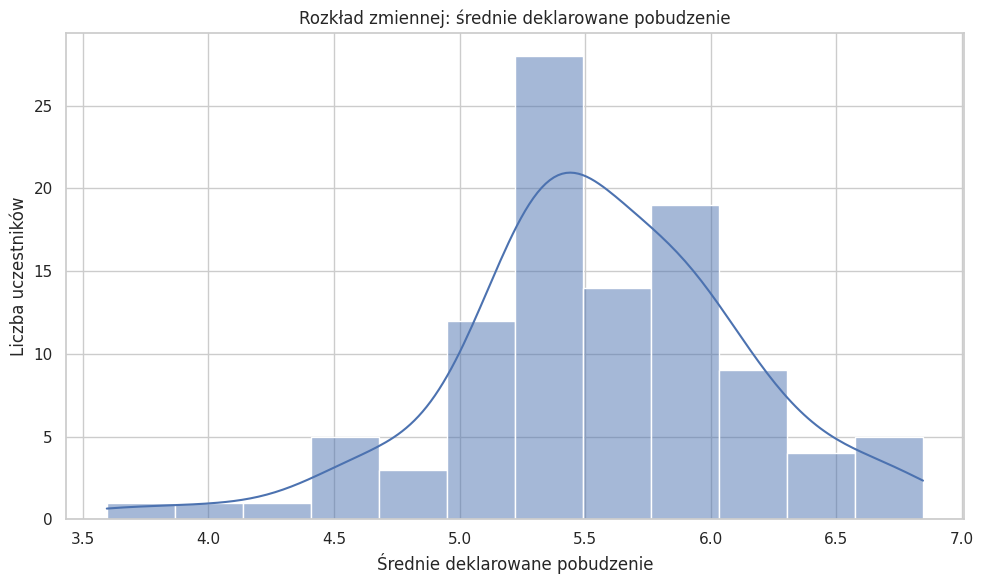

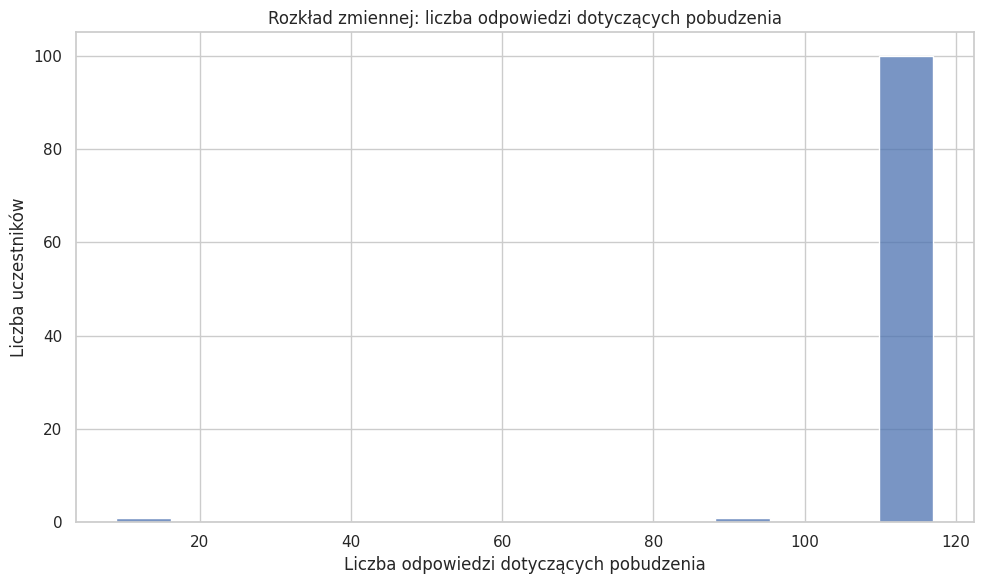

In [11]:
# Pobiera czytelną nazwę wybranej zmiennej subiektywnej.
nazwa_zmiennej_subiektywnej = NAZWY_ZMIENNYCH.get(
    ZMIENNA_SUBIEKTYWNA,
    ZMIENNA_SUBIEKTYWNA,
)

# Pobiera czytelną nazwę kolumny z liczbą odpowiedzi.
nazwa_liczby_odpowiedzi = NAZWY_ZMIENNYCH.get(
    KOLUMNA_LICZBY_ODPOWIEDZI,
    KOLUMNA_LICZBY_ODPOWIEDZI,
)

# Tworzy obszar wykresu rozkładu wybranej zmiennej.
plt.figure(figsize=(10, 6))

# Rysuje histogram wybranej zmiennej subiektywnej.
sns.histplot(
    # Przekazuje zagregowane dane uczestników.
    data=subjective_per_subject,
    # Ustawia wybraną zmienną na osi poziomej.
    x=ZMIENNA_SUBIEKTYWNA,
    # Ustawia liczbę przedziałów histogramu.
    bins=12,
    # Dodaje estymację gęstości rozkładu.
    kde=True,
)

# Ustawia tytuł wykresu.
plt.title(
    f"Rozkład zmiennej: {nazwa_zmiennej_subiektywnej}"
)

# Ustawia opis osi poziomej.
plt.xlabel(nazwa_zmiennej_subiektywnej.capitalize())

# Ustawia opis osi pionowej.
plt.ylabel("Liczba uczestników")

# Dopasowuje rozmieszczenie elementów wykresu.
plt.tight_layout()

# Wyświetla wykres.
plt.show()

# Tworzy obszar wykresu liczby odpowiedzi.
plt.figure(figsize=(10, 6))

# Rysuje histogram liczby odpowiedzi uczestników.
sns.histplot(
    # Przekazuje zagregowane dane uczestników.
    data=subjective_per_subject,
    # Ustawia kolumnę z liczbą odpowiedzi na osi poziomej.
    x=KOLUMNA_LICZBY_ODPOWIEDZI,
    # Ustawia liczbę przedziałów histogramu.
    bins=15,
)

# Ustawia tytuł wykresu.
plt.title(
    f"Rozkład zmiennej: {nazwa_liczby_odpowiedzi}"
)

# Ustawia opis osi poziomej.
plt.xlabel(nazwa_liczby_odpowiedzi.capitalize())

# Ustawia opis osi pionowej.
plt.ylabel("Liczba uczestników")

# Dopasowuje rozmieszczenie elementów wykresu.
plt.tight_layout()

# Wyświetla wykres.
plt.show()


## 5. Pre-processing i ekstrakcja charakterystyk sygnału EDA

Sygnał EDA składa się z dwóch głównych części:

* składowej tonicznej, która opisuje wolnozmienny poziom przewodnictwa skóry,
* składowej fazowej, która zawiera krótkotrwałe reakcje SCR związane z pobudzeniem.

Dla każdego uczestnika wyznaczamy:

* długość zapisu,
* całkowitą liczbę pików SCR,
* liczbę pików SCR na minutę,
* średnią i medianę amplitudy pików,
* maksymalną amplitudę piku,
* średnią i odchylenie standardowe składowej tonicznej,
* średnią i odchylenie standardowe składowej fazowej.

Liczba pików na minutę jest lepszą miarą porównawczą niż sama liczba pików, ponieważ uwzględnia możliwe różnice długości nagrań.


In [12]:
# Definiuje funkcję `pobierz_id_z_nazwy_pliku`.
def pobierz_id_z_nazwy_pliku(sciezka):
    # Oblicza lub przygotowuje wartość zmiennej `nazwa`.
    nazwa = os.path.basename(sciezka)
    # Oblicza lub przygotowuje wartość zmiennej `identyfikator`.
    identyfikator = nazwa.split("-")[0].replace("SUB", "").lstrip("0")
    # Zwraca obliczony wynik z funkcji.
    return identyfikator if identyfikator else "0"

# Definiuje funkcję `bezpieczna_srednia`.
def bezpieczna_srednia(wartosci):
    # Oblicza lub przygotowuje wartość zmiennej `wartosci`.
    wartosci = np.asarray(wartosci, dtype=float)
    # Oblicza lub przygotowuje wartość zmiennej `wartosci`.
    wartosci = wartosci[np.isfinite(wartosci)]
    # Zwraca obliczony wynik z funkcji.
    return float(np.mean(wartosci)) if len(wartosci) else np.nan

# Definiuje funkcję `bezpieczna_mediana`.
def bezpieczna_mediana(wartosci):
    # Oblicza lub przygotowuje wartość zmiennej `wartosci`.
    wartosci = np.asarray(wartosci, dtype=float)
    # Oblicza lub przygotowuje wartość zmiennej `wartosci`.
    wartosci = wartosci[np.isfinite(wartosci)]
    # Zwraca obliczony wynik z funkcji.
    return float(np.median(wartosci)) if len(wartosci) else np.nan

# Definiuje funkcję `bezpieczne_maksimum`.
def bezpieczne_maksimum(wartosci):
    # Oblicza lub przygotowuje wartość zmiennej `wartosci`.
    wartosci = np.asarray(wartosci, dtype=float)
    # Oblicza lub przygotowuje wartość zmiennej `wartosci`.
    wartosci = wartosci[np.isfinite(wartosci)]
    # Zwraca obliczony wynik z funkcji.
    return float(np.max(wartosci)) if len(wartosci) else np.nan

# Definiuje funkcję `przetworz_eda`.
def przetworz_eda(sciezka, sampling_rate=CZESTOTLIWOSC_PROBKOWANIA):
    # Oblicza lub przygotowuje wartość zmiennej `identyfikator`.
    identyfikator = pobierz_id_z_nazwy_pliku(sciezka)

    # Oblicza lub przygotowuje wartość zmiennej `dane`.
    dane = pd.read_csv(
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        sciezka,
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        usecols=lambda nazwa: nazwa.upper() == "EDA",
    # Kończy wcześniejsze wywołanie funkcji lub definicję struktury.
    )

    # Sprawdza, czy podany warunek jest spełniony.
    if dane.empty or "EDA" not in dane.columns:
        # Przerywa działanie funkcji i zgłasza opisany błąd.
        raise ValueError("Brak kolumny EDA.")

    # Oblicza lub przygotowuje wartość zmiennej `eda`.
    eda = pd.to_numeric(dane["EDA"], errors="coerce")
    # Oblicza lub przygotowuje wartość zmiennej `eda`.
    eda = eda.interpolate(limit_direction="both").dropna()

    # Sprawdza, czy podany warunek jest spełniony.
    if len(eda) < sampling_rate * 10:
        # Przerywa działanie funkcji i zgłasza opisany błąd.
        raise ValueError("Sygnał jest krótszy niż 10 sekund.")

    # Oblicza lub przygotowuje wartość zmiennej `sygnaly, informacje`.
    sygnaly, informacje = nk.eda_process(
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        eda,
        # Oblicza lub przygotowuje wartość zmiennej `sampling_rate`.
        sampling_rate=sampling_rate,
    # Kończy wcześniejsze wywołanie funkcji lub definicję struktury.
    )

    # Oblicza lub przygotowuje wartość zmiennej `czas_minuty`.
    czas_minuty = len(eda) / sampling_rate / 60
    # Oblicza lub przygotowuje wartość zmiennej `indeksy_pikow`.
    indeksy_pikow = informacje.get("SCR_Peaks", [])
    # Oblicza lub przygotowuje wartość zmiennej `amplitudy`.
    amplitudy = informacje.get("SCR_Amplitude", [])

    # Oblicza lub przygotowuje wartość zmiennej `wynik`.
    wynik = {
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "ID": identyfikator,
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Duration_Min": czas_minuty,
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Peaks_Count": len(indeksy_pikow),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Peaks_Per_Min": len(indeksy_pikow) / czas_minuty,
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "SCR_Amplitude_Mean": bezpieczna_srednia(amplitudy),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "SCR_Amplitude_Median": bezpieczna_mediana(amplitudy),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "SCR_Amplitude_Max": bezpieczne_maksimum(amplitudy),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Tonic_Mean": sygnaly["EDA_Tonic"].mean(),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Tonic_SD": sygnaly["EDA_Tonic"].std(),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Phasic_Mean": sygnaly["EDA_Phasic"].mean(),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Phasic_SD": sygnaly["EDA_Phasic"].std(),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Raw_Mean": eda.mean(),
        # Przekazuje kolejny argument lub element do tworzonej struktury.
        "EDA_Raw_SD": eda.std(),
    # Kończy tworzenie słownika.
    }

    # Zwraca obliczony wynik z funkcji.
    return wynik


In [13]:
# Ekstrakcja cech może trwać długo, dlatego zapisujemy wynik do pliku.
# Oblicza lub przygotowuje wartość zmiennej `PLIK_CECH_EDA`.
PLIK_CECH_EDA = KATALOG_WYNIKOW / "cechy_eda.csv"

# Sprawdza, czy podany warunek jest spełniony.
if PLIK_CECH_EDA.exists():
    # Wyświetla informację lub wynik w notebooku.
    print("Wczytywanie wcześniej obliczonych charakterystyk EDA.")
    # Oblicza lub przygotowuje wartość zmiennej `eda_df`.
    eda_df = pd.read_csv(PLIK_CECH_EDA, dtype={"ID": str})
# Wykonuje ten fragment, gdy wcześniejsze warunki nie zostały spełnione.
else:
    # Oblicza lub przygotowuje wartość zmiennej `wybrane_pliki`.
    wybrane_pliki = pliki_biosygnalow

    # Sprawdza, czy podany warunek jest spełniony.
    if MAKSYMALNA_LICZBA_OSOB is not None:
        # Oblicza lub przygotowuje wartość zmiennej `wybrane_pliki`.
        wybrane_pliki = wybrane_pliki[:MAKSYMALNA_LICZBA_OSOB]

    # Oblicza lub przygotowuje wartość zmiennej `wyniki_eda`.
    wyniki_eda = []
    # Oblicza lub przygotowuje wartość zmiennej `bledy_eda`.
    bledy_eda = []

    # Wyświetla informację lub wynik w notebooku.
    print(f"Rozpoczynam analizę {len(wybrane_pliki)} plików.")

    # Rozpoczyna pętlę wykonującą operację dla kolejnych elementów.
    for numer, plik in enumerate(wybrane_pliki, start=1):
        # Oblicza lub przygotowuje wartość zmiennej `identyfikator`.
        identyfikator = pobierz_id_z_nazwy_pliku(plik)

        # Rozpoczyna blok przechwytujący ewentualne błędy.
        try:
            # Wykonuje opisaną operację w bieżącym etapie analizy.
            wyniki_eda.append(przetworz_eda(plik))
        # Obsługuje błąd powstały podczas wykonywania wcześniejszego bloku.
        except Exception as blad:
            # Wykonuje opisaną operację w bieżącym etapie analizy.
            bledy_eda.append({
                # Przekazuje kolejny argument lub element do tworzonej struktury.
                "ID": identyfikator,
                # Przekazuje kolejny argument lub element do tworzonej struktury.
                "Plik": plik,
                # Przekazuje kolejny argument lub element do tworzonej struktury.
                "Blad": str(blad),
            # Kończy tworzenie słownika.
            })

        # Sprawdza, czy podany warunek jest spełniony.
        if numer % 10 == 0 or numer == len(wybrane_pliki):
            # Wyświetla informację lub wynik w notebooku.
            print(f"Przetworzono {numer} z {len(wybrane_pliki)} plików.")

        # Zwalnia nieużywaną pamięć po przetworzeniu pliku.
        gc.collect()

    # Oblicza lub przygotowuje wartość zmiennej `eda_df`.
    eda_df = pd.DataFrame(wyniki_eda)
    # Oblicza lub przygotowuje wartość zmiennej `eda_df.to_csv(PLIK_CECH_EDA, index`.
    eda_df.to_csv(PLIK_CECH_EDA, index=False)

    # Sprawdza, czy podany warunek jest spełniony.
    if bledy_eda:
        # Wykonuje operację na danych za pomocą biblioteki pandas.
        pd.DataFrame(bledy_eda).to_csv(
            # Przekazuje kolejny argument lub element do tworzonej struktury.
            KATALOG_WYNIKOW / "bledy_przetwarzania_eda.csv",
            # Oblicza lub przygotowuje wartość zmiennej `index`.
            index=False,
        # Kończy wcześniejsze wywołanie funkcji lub definicję struktury.
        )

# Wyświetla informację lub wynik w notebooku.
print(f"Liczba poprawnie przetworzonych uczestników: {len(eda_df)}")
# Wyświetla tabelę w czytelnej postaci.
display(eda_df.head())


Rozpoczynam analizę 102 plików.
Przetworzono 10 z 102 plików.
Przetworzono 20 z 102 plików.
Przetworzono 30 z 102 plików.
Przetworzono 40 z 102 plików.
Przetworzono 50 z 102 plików.
Przetworzono 60 z 102 plików.
Przetworzono 70 z 102 plików.
Przetworzono 80 z 102 plików.
Przetworzono 90 z 102 plików.
Przetworzono 100 z 102 plików.
Przetworzono 102 z 102 plików.
Liczba poprawnie przetworzonych uczestników: 102


,ID,EDA_Duration_Min,EDA_Peaks_Count,EDA_Peaks_Per_Min,SCR_Amplitude_Mean,SCR_Amplitude_Median,SCR_Amplitude_Max,EDA_Tonic_Mean,EDA_Tonic_SD,EDA_Phasic_Mean,EDA_Phasic_SD,EDA_Raw_Mean,EDA_Raw_SD
0,103,61.283333,66,1.076965,4.190234e-07,2.652167e-07,0.000004,0.000254,0.000022,-5.375653e-11,1.109542e-07,0.000254,0.000022
1,119,50.566667,10,0.197759,1.271399e-05,9.007307e-06,0.000044,0.000114,0.000006,-3.444795e-10,7.338466e-07,0.000114,0.000006
2,120,48.783333,20,0.409976,7.933308e-06,3.219215e-06,0.000052,0.000115,0.000009,2.594603e-11,1.039373e-06,0.000115,0.000009
3,136,49.300000,6,0.121704,8.440673e-06,1.036131e-06,0.000030,0.000225,0.000055,-2.132829e-11,6.337666e-07,0.000225,0.000055
4,141,48.066667,20,0.416089,2.403227e-05,7.823400e-06,0.000112,0.000398,0.000004,-4.233333e-09,1.970565e-06,0.000398,0.000004


In [14]:
# Kontrola jakości wyekstrahowanych charakterystyk.
# Wyświetla informację lub wynik w notebooku.
print("Statystyki charakterystyk EDA:")
# Wyświetla tabelę w czytelnej postaci.
display(eda_df.describe().T.round(3))

# Oblicza lub przygotowuje wartość zmiennej `braki_eda`.
braki_eda = (
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    eda_df
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .isna()
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .mean()
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .mul(100)
    # Oblicza lub przygotowuje wartość zmiennej `.sort_values(ascending`.
    .sort_values(ascending=False)
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .rename("Braki_procent")
    # Wykonuje opisaną operację w bieżącym etapie analizy.
    .to_frame()
# Kończy wcześniejsze wywołanie funkcji lub definicję struktury.
)

# Wyświetla informację lub wynik w notebooku.
print("Braki w tabeli charakterystyk EDA:")
# Wyświetla tabelę w czytelnej postaci.
display(braki_eda.round(2))


Statystyki charakterystyk EDA:


,count,mean,std,min,25%,50%,75%,max
EDA_Duration_Min,102.0,46.414,11.841,1.30,47.800,48.967,50.654,61.283
EDA_Peaks_Count,102.0,84.216,197.762,1.00,14.000,28.500,66.000,1613.000
EDA_Peaks_Per_Min,102.0,3.066,8.135,0.02,0.303,0.608,1.874,49.333
SCR_Amplitude_Mean,101.0,0.000,0.000,0.00,0.000,0.000,0.000,0.000
SCR_Amplitude_Median,101.0,0.000,0.000,0.00,0.000,0.000,0.000,0.000
SCR_Amplitude_Max,101.0,0.000,0.000,0.00,0.000,0.000,0.000,0.000
EDA_Tonic_Mean,102.0,0.000,0.000,0.00,0.000,0.000,0.000,0.000
EDA_Tonic_SD,102.0,0.000,0.000,0.00,0.000,0.000,0.000,0.000
EDA_Phasic_Mean,102.0,0.000,0.000,-0.00,-0.000,-0.000,0.000,0.000
EDA_Phasic_SD,102.0,0.000,0.000,0.00,0.000,0.000,0.000,0.000


Braki w tabeli charakterystyk EDA:


,Braki_procent
SCR_Amplitude_Mean,0.98
SCR_Amplitude_Max,0.98
SCR_Amplitude_Median,0.98
ID,0.00
EDA_Duration_Min,0.00
EDA_Peaks_Per_Min,0.00
EDA_Peaks_Count,0.00
EDA_Tonic_Mean,0.00
EDA_Tonic_SD,0.00
EDA_Phasic_Mean,0.00


## 6. Połączenie danych subiektywnych i fizjologicznych

Dane subiektywne i charakterystyki sygnału EDA są łączone na podstawie identyfikatora uczestnika. Kontrola jakości uwzględnia długość nagrania EDA oraz liczbę odpowiedzi dotyczącą zmiennej wybranej w ustawieniach projektu.


In [15]:
# Łączy dane subiektywne z charakterystykami sygnału EDA.
final_data = pd.merge(
    # Przekazuje zagregowane odpowiedzi uczestników.
    subjective_per_subject,
    # Przekazuje tabelę charakterystyk EDA.
    eda_df,
    # Łączy tabele na podstawie identyfikatora uczestnika.
    on="ID",
    # Pozostawia uczestników występujących w obu tabelach.
    how="inner",
    # Sprawdza relację jeden do jednego.
    validate="one_to_one",
)

# Oblicza medianę długości nagrania EDA.
mediana_dlugosci_nagrania = final_data[
    "EDA_Duration_Min"
].median()

# Oblicza medianę liczby odpowiedzi dla wybranej zmiennej subiektywnej.
mediana_liczby_odpowiedzi = final_data[
    KOLUMNA_LICZBY_ODPOWIEDZI
].median()

# Ustala minimalną długość nagrania jako połowę mediany.
minimalna_dlugosc_nagrania = (
    0.5 * mediana_dlugosci_nagrania
)

# Ustala minimalną liczbę odpowiedzi jako połowę mediany.
minimalna_liczba_odpowiedzi = (
    0.5 * mediana_liczby_odpowiedzi
)

# Wybiera uczestników spełniających warunki jakości danych.
final_data = final_data[
    # Sprawdza wymaganą długość nagrania EDA.
    (
        final_data["EDA_Duration_Min"]
        >= minimalna_dlugosc_nagrania
    )
    # Łączy oba warunki jakości za pomocą operatora AND.
    & (
        # Sprawdza wymaganą liczbę odpowiedzi subiektywnych.
        final_data[KOLUMNA_LICZBY_ODPOWIEDZI]
        >= minimalna_liczba_odpowiedzi
    )
].copy()

# Usuwa obserwacje bez wartości wybranej zmiennej subiektywnej.
final_data = final_data[
    final_data[ZMIENNA_SUBIEKTYWNA].notna()
].copy()

# Usuwa obserwacje bez wartości wybranej charakterystyki EDA.
final_data = final_data[
    final_data[CECHA_EDA_GLOWNA].notna()
].copy()

# Resetuje indeks po kontroli jakości.
final_data = final_data.reset_index(drop=True)

# Wyświetla minimalną zaakceptowaną długość nagrania.
print(
    "Minimalna zaakceptowana długość nagrania EDA: "
    f"{minimalna_dlugosc_nagrania:.2f} min"
)

# Wyświetla minimalną zaakceptowaną liczbę odpowiedzi.
print(
    "Minimalna zaakceptowana liczba odpowiedzi dla zmiennej „"
    f"{NAZWY_ZMIENNYCH[ZMIENNA_SUBIEKTYWNA]}”: "
    f"{minimalna_liczba_odpowiedzi:.0f}"
)

# Wyświetla liczbę uczestników po kontroli jakości.
print(
    "Liczba uczestników po kontroli jakości: "
    f"{len(final_data)}"
)

# Wyświetla pierwsze wiersze danych końcowych.
display(final_data.head())

# Zapisuje dane końcowe do pliku CSV.
final_data.to_csv(
    # Ustawia ścieżkę pliku wynikowego.
    KATALOG_WYNIKOW / "dane_koncowe.csv",
    # Pomija indeks tabeli.
    index=False,
)


Minimalna zaakceptowana długość nagrania EDA: 24.48 min
Minimalna zaakceptowana liczba odpowiedzi dla zmiennej „średnie deklarowane pobudzenie”: 58
Liczba uczestników po kontroli jakości: 95


,ID,Mean_Arousal,Median_Arousal,SD_Arousal,Min_Arousal,Max_Arousal,Arousal_Responses,Mean_Valence,Median_Valence,SD_Valence,...,EDA_Peaks_Per_Min,SCR_Amplitude_Mean,SCR_Amplitude_Median,SCR_Amplitude_Max,EDA_Tonic_Mean,EDA_Tonic_SD,EDA_Phasic_Mean,EDA_Phasic_SD,EDA_Raw_Mean,EDA_Raw_SD
0,103,5.284547,5.365,1.374648,2.039,7.812,117,5.036179,5.000,2.102953,...,1.076965,4.190234e-07,2.652167e-07,0.000004,0.000254,0.000022,-5.375653e-11,1.109542e-07,0.000254,0.000022
1,119,5.982761,5.000,2.138401,1.000,9.000,117,4.320333,5.000,3.289103,...,0.197759,1.271399e-05,9.007307e-06,0.000044,0.000114,0.000006,-3.444795e-10,7.338466e-07,0.000114,0.000006
2,120,5.919487,5.697,1.059742,3.382,9.000,117,3.764607,2.491,2.843719,...,0.409976,7.933308e-06,3.219215e-06,0.000052,0.000115,0.000009,2.594603e-11,1.039373e-06,0.000115,0.000009
3,136,5.494718,5.785,1.831524,1.000,9.000,117,4.951282,5.000,2.185089,...,0.121704,8.440673e-06,1.036131e-06,0.000030,0.000225,0.000055,-2.132829e-11,6.337666e-07,0.000225,0.000055
4,141,6.085060,9.000,3.371109,1.000,9.000,117,5.174376,5.000,3.792192,...,0.416089,2.403227e-05,7.823400e-06,0.000112,0.000398,0.000004,-4.233333e-09,1.970565e-06,0.000398,0.000004


In [16]:
# Tworzy listę najważniejszych zmiennych dla aktualnej konfiguracji.
glowne_zmienne = [
    # Dodaje wybraną zmienną subiektywną.
    ZMIENNA_SUBIEKTYWNA,
    # Dodaje wybraną główną charakterystykę EDA.
    CECHA_EDA_GLOWNA,
    # Dodaje liczbę odpowiedzi dotyczącą wybranej zmiennej.
    KOLUMNA_LICZBY_ODPOWIEDZI,
    # Dodaje długość nagrania EDA.
    "EDA_Duration_Min",
    # Dodaje średnią amplitudę pików SCR.
    "SCR_Amplitude_Mean",
    # Dodaje średni poziom składowej tonicznej.
    "EDA_Tonic_Mean",
    # Dodaje zmienność składowej fazowej.
    "EDA_Phasic_SD",
]

# Usuwa powtarzające się nazwy zmiennych.
glowne_zmienne = list(
    dict.fromkeys(glowne_zmienne)
)

# Pozostawia wyłącznie kolumny dostępne w danych końcowych.
glowne_zmienne = [
    zmienna
    for zmienna in glowne_zmienne
    if zmienna in final_data.columns
]

# Wyświetla nagłówek tabeli statystyk opisowych.
print("STATYSTYKI OPISOWE GŁÓWNYCH ZMIENNYCH")

# Wyświetla statystyki opisowe wybranych zmiennych.
display(
    final_data[glowne_zmienne]
    .describe()
    .T
    .round(3)
)


STATYSTYKI OPISOWE GŁÓWNYCH ZMIENNYCH


,count,mean,std,min,25%,50%,75%,max
Mean_Arousal,95.0,5.538,0.560,3.595,5.266,5.467,5.890,6.846
EDA_Peaks_Per_Min,95.0,1.803,4.289,0.020,0.289,0.563,1.342,33.534
Arousal_Responses,95.0,116.726,2.668,91.000,117.000,117.000,117.000,117.000
EDA_Duration_Min,95.0,49.492,2.703,41.350,48.025,49.033,50.742,61.283
SCR_Amplitude_Mean,95.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
EDA_Tonic_Mean,95.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000
EDA_Phasic_SD,95.0,0.000,0.000,0.000,0.000,0.000,0.000,0.000


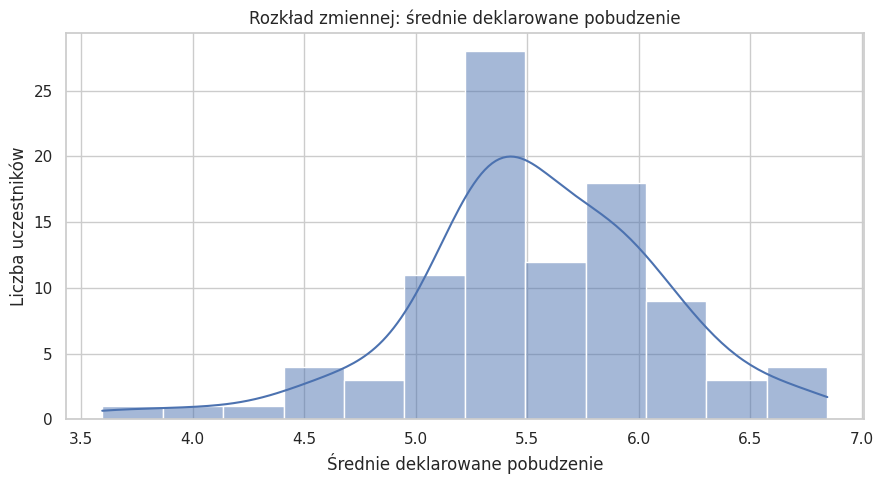

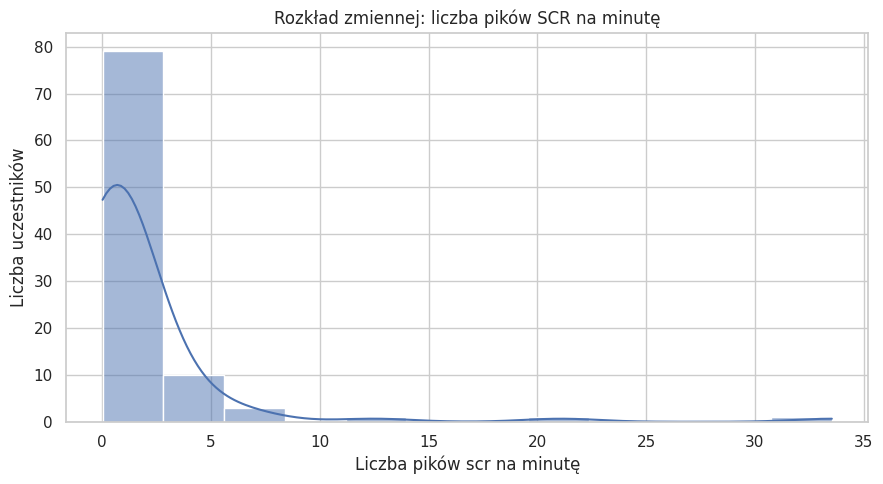

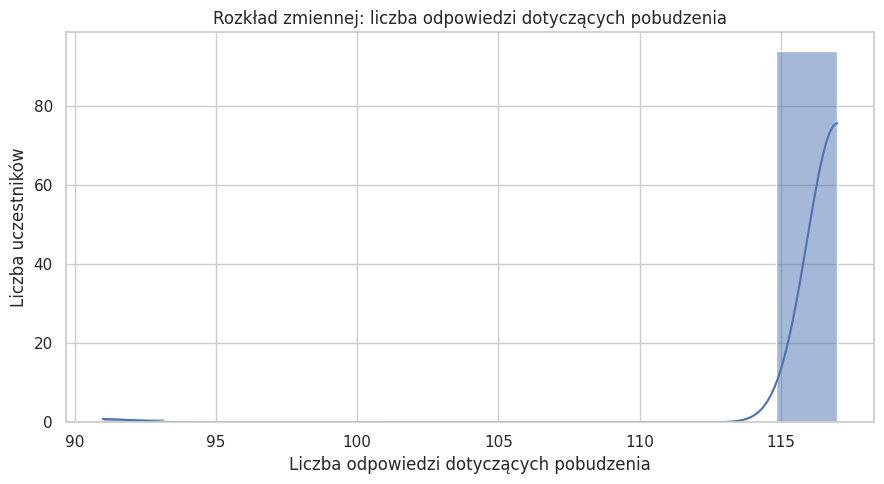

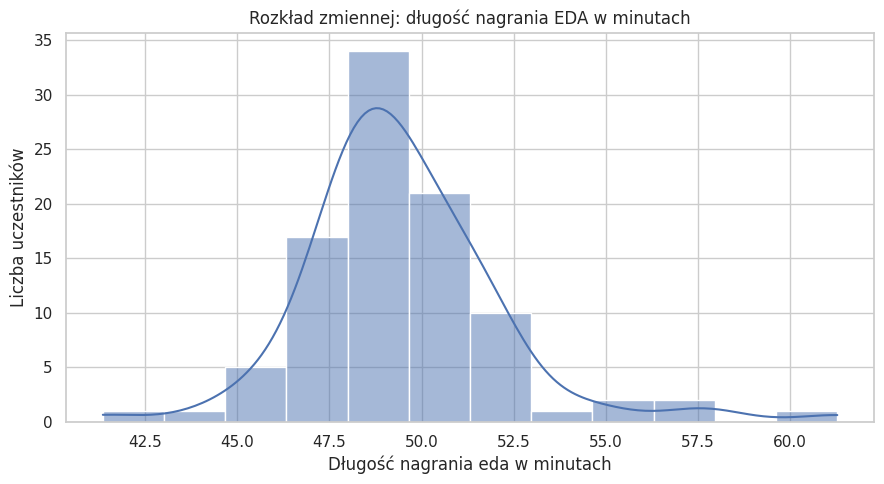

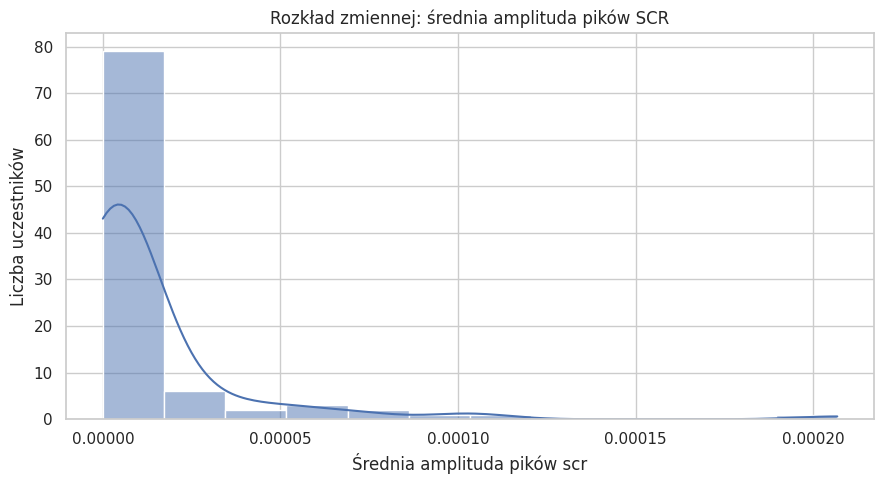

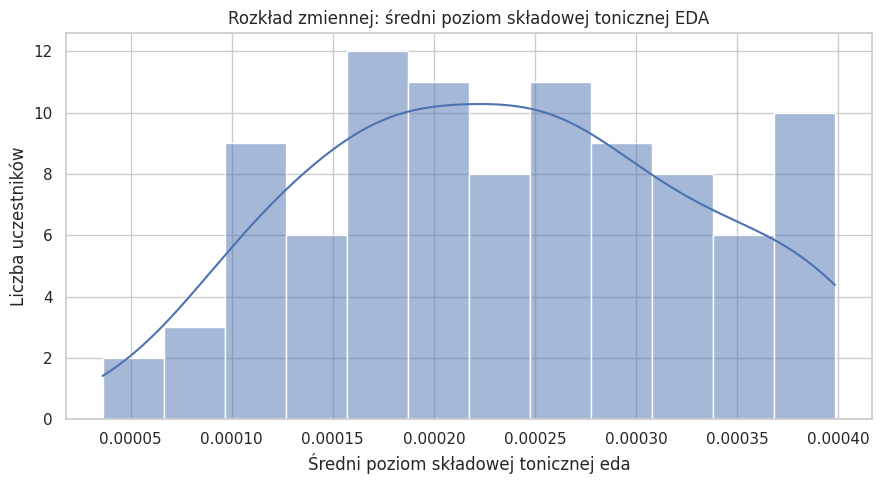

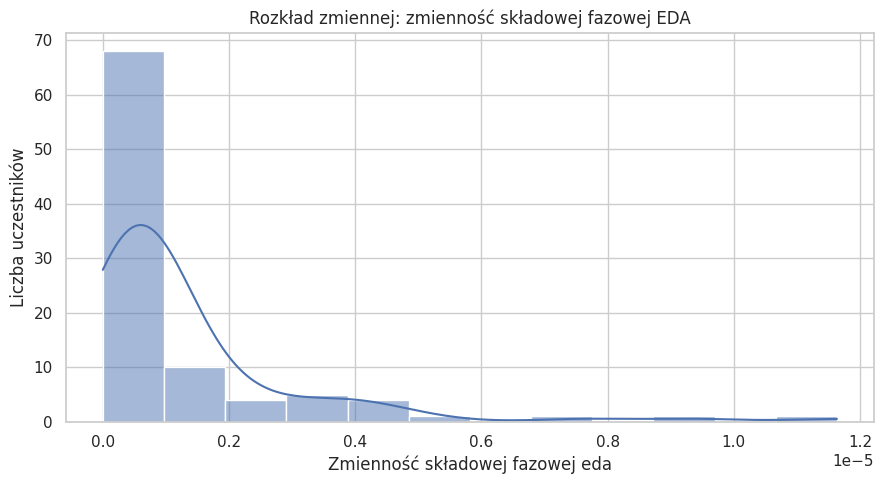

In [17]:
# Tworzy osobny wykres dla każdej głównej zmiennej.
for zmienna in glowne_zmienne:
    # Pobiera czytelną nazwę aktualnej zmiennej.
    nazwa_zmiennej = NAZWY_ZMIENNYCH.get(
        zmienna,
        zmienna,
    )

    # Tworzy nowy obszar wykresu.
    plt.figure(figsize=(9, 5))

    # Rysuje histogram rozkładu aktualnej zmiennej.
    sns.histplot(
        # Przekazuje dane końcowe.
        data=final_data,
        # Ustawia aktualną zmienną na osi poziomej.
        x=zmienna,
        # Ustawia liczbę przedziałów histogramu.
        bins=12,
        # Dodaje estymację gęstości rozkładu.
        kde=True,
    )

    # Ustawia tytuł wykresu.
    plt.title(
        f"Rozkład zmiennej: {nazwa_zmiennej}"
    )

    # Ustawia opis osi poziomej.
    plt.xlabel(nazwa_zmiennej.capitalize())

    # Ustawia opis osi pionowej.
    plt.ylabel("Liczba uczestników")

    # Dopasowuje rozmieszczenie elementów wykresu.
    plt.tight_layout()

    # Wyświetla wykres.
    plt.show()


## 7. Obserwacje odstające

Obserwacje odstające są identyfikowane metodą IQR. Nie są automatycznie usuwane, ponieważ mogą przedstawiać rzeczywistą, silną reakcję fizjologiczną. Wynik podstawowy obliczamy dla pełnego zbioru, a następnie wykonujemy analizę wrażliwości po pominięciu skrajnych obserwacji.


In [18]:
# Definiuje funkcję identyfikującą obserwacje nieodstające metodą IQR.
def maska_bez_odstajacych_iqr(
    dane,
    kolumna,
):
    # Oblicza pierwszy kwartyl analizowanej zmiennej.
    q1 = dane[kolumna].quantile(0.25)

    # Oblicza trzeci kwartyl analizowanej zmiennej.
    q3 = dane[kolumna].quantile(0.75)

    # Oblicza rozstęp międzykwartylowy.
    iqr = q3 - q1

    # Oblicza dolną granicę wartości nieodstających.
    dolna_granica = q1 - 1.5 * iqr

    # Oblicza górną granicę wartości nieodstających.
    gorna_granica = q3 + 1.5 * iqr

    # Zwraca maskę obserwacji mieszczących się w granicach IQR.
    return dane[kolumna].between(
        dolna_granica,
        gorna_granica,
    )


# Wyznacza obserwacje nieodstające dla wybranej zmiennej subiektywnej.
maska_zmiennej_subiektywnej = maska_bez_odstajacych_iqr(
    final_data,
    ZMIENNA_SUBIEKTYWNA,
)

# Wyznacza obserwacje nieodstające dla wybranej charakterystyki EDA.
maska_glownej_cechy_eda = maska_bez_odstajacych_iqr(
    final_data,
    CECHA_EDA_GLOWNA,
)

# Łączy maski obu analizowanych zmiennych.
maska_laczna = (
    maska_zmiennej_subiektywnej
    & maska_glownej_cechy_eda
)

# Tworzy zbiór bez obserwacji odstających.
dane_bez_odstajacych = final_data[
    maska_laczna
].copy()

# Wyświetla liczbę wszystkich obserwacji.
print(
    "Liczba wszystkich obserwacji: "
    f"{len(final_data)}"
)

# Wyświetla liczbę obserwacji po filtracji IQR.
print(
    "Liczba obserwacji po filtracji IQR: "
    f"{len(dane_bez_odstajacych)}"
)

# Wyświetla liczbę obserwacji odstających.
print(
    "Liczba obserwacji odstających: "
    f"{(~maska_laczna).sum()}"
)


Liczba wszystkich obserwacji: 95
Liczba obserwacji po filtracji IQR: 77
Liczba obserwacji odstających: 18


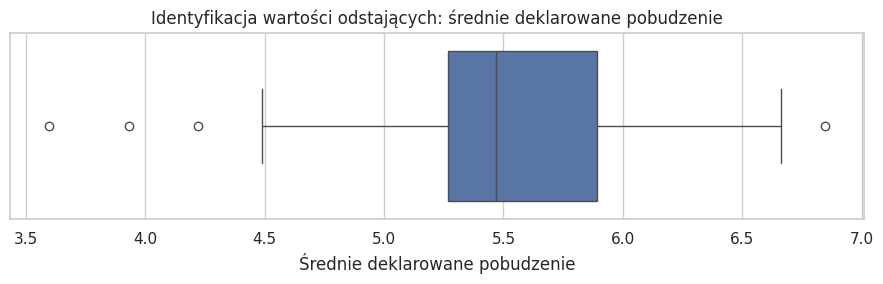

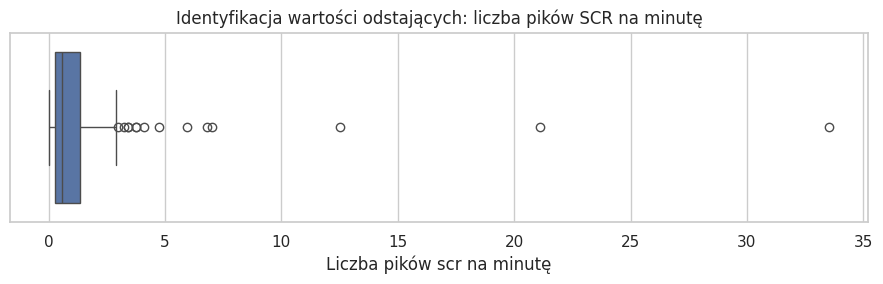

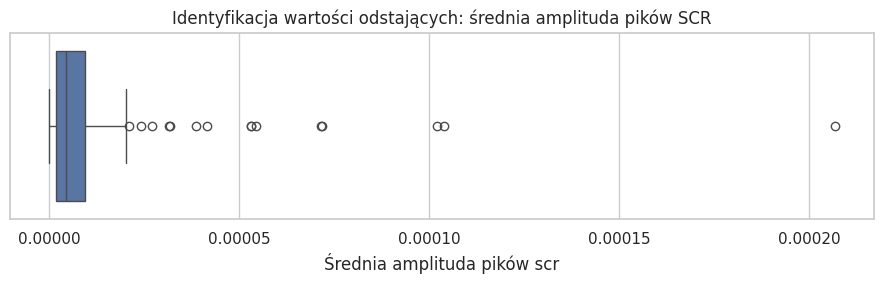

In [19]:
# Tworzy listę zmiennych przedstawianych na wykresach pudełkowych.
zmienne_wykresow_pudelkowych = [
    # Dodaje wybraną zmienną subiektywną.
    ZMIENNA_SUBIEKTYWNA,
    # Dodaje wybraną główną charakterystykę EDA.
    CECHA_EDA_GLOWNA,
    # Dodaje średnią amplitudę pików SCR jako zmienną uzupełniającą.
    "SCR_Amplitude_Mean",
]

# Usuwa powtarzające się nazwy zmiennych.
zmienne_wykresow_pudelkowych = list(
    dict.fromkeys(zmienne_wykresow_pudelkowych)
)

# Pozostawia wyłącznie zmienne dostępne w tabeli końcowej.
zmienne_wykresow_pudelkowych = [
    zmienna
    for zmienna in zmienne_wykresow_pudelkowych
    if zmienna in final_data.columns
]

# Tworzy wykres pudełkowy dla każdej wybranej zmiennej.
for zmienna in zmienne_wykresow_pudelkowych:
    # Pobiera czytelną nazwę aktualnej zmiennej.
    nazwa_zmiennej = NAZWY_ZMIENNYCH.get(
        zmienna,
        zmienna,
    )

    # Tworzy nowy obszar wykresu.
    plt.figure(figsize=(9, 3))

    # Rysuje wykres pudełkowy aktualnej zmiennej.
    sns.boxplot(
        # Przekazuje dane końcowe.
        data=final_data,
        # Ustawia aktualną zmienną na osi poziomej.
        x=zmienna,
    )

    # Ustawia tytuł wykresu.
    plt.title(
        f"Identyfikacja wartości odstających: {nazwa_zmiennej}"
    )

    # Ustawia opis osi poziomej.
    plt.xlabel(nazwa_zmiennej.capitalize())

    # Dopasowuje rozmieszczenie elementów wykresu.
    plt.tight_layout()

    # Wyświetla wykres.
    plt.show()


## 8. Weryfikacja normalności rozkładów

Normalność rozkładów wybranej zmiennej subiektywnej i głównej charakterystyki EDA jest oceniana testem Shapiro-Wilka. Decyzja o zastosowaniu korelacji Pearsona albo Spearmana jest podejmowana automatycznie z wykorzystaniem poziomu istotności określonego w ustawieniach projektu.


In [20]:
# Definiuje funkcję wykonującą testy normalności.
def test_normalnosci(
    dane,
    kolumny,
    poziom_istotnosci,
):
    # Tworzy pustą listę na wyniki testów.
    wyniki = []

    # Analizuje każdą przekazaną kolumnę.
    for kolumna in kolumny:
        # Usuwa braki danych z aktualnej zmiennej.
        oczyszczone = dane[kolumna].dropna()

        # Pomija zmienną przy zbyt małej liczbie obserwacji.
        if len(oczyszczone) < 3:
            # Przechodzi do kolejnej zmiennej.
            continue

        # Wykonuje test Shapiro-Wilka.
        statystyka, p_value = stats.shapiro(
            oczyszczone
        )

        # Dodaje wynik testu do listy.
        wyniki.append({
            # Zapisuje czytelną nazwę zmiennej.
            "Zmienna": NAZWY_ZMIENNYCH.get(
                kolumna,
                kolumna,
            ),
            # Zapisuje statystykę testową.
            "W": statystyka,
            # Zapisuje wartość p.
            "p_value": p_value,
            # Zapisuje decyzję dotyczącą normalności rozkładu.
            "Rozkład zgodny z normalnym": (
                p_value >= poziom_istotnosci
            ),
        })

    # Zwraca tabelę wyników.
    return pd.DataFrame(wyniki)


# Tworzy listę zmiennych objętych testem normalności.
zmienne_testu_normalnosci = [
    # Dodaje wybraną zmienną subiektywną.
    ZMIENNA_SUBIEKTYWNA,
    # Dodaje wybraną główną charakterystykę EDA.
    CECHA_EDA_GLOWNA,
]

# Usuwa ewentualne powtórzenia nazw zmiennych.
zmienne_testu_normalnosci = list(
    dict.fromkeys(zmienne_testu_normalnosci)
)

# Wykonuje testy normalności dla aktualnej konfiguracji.
wyniki_normalnosci = test_normalnosci(
    final_data,
    zmienne_testu_normalnosci,
    POZIOM_ISTOTNOSCI,
)

# Wyświetla tabelę wyników testów normalności.
display(wyniki_normalnosci.round(4))


,Zmienna,W,p_value,Rozkład zgodny z normalnym
0,średnie deklarowane pobudzenie,0.9688,0.0227,False
1,liczba pików SCR na minutę,0.3821,0.0000,False


## 9. Główna analiza korelacji

Główna analiza sprawdza zależność pomiędzy zmienną subiektywną i charakterystyką EDA wybranymi w ustawieniach projektu. Metoda korelacji jest dobierana automatycznie na podstawie wyników testów normalności.

Oprócz współczynnika korelacji i wartości `p` obliczany jest bootstrapowy 95-procentowy przedział ufności.


In [21]:
# Definiuje funkcję wykonującą główną analizę korelacji.
def oblicz_korelacje(
    dane,
    zmienna_x,
    zmienna_y,
    poziom_istotnosci,
):
    # Wybiera kompletne obserwacje dla obu analizowanych zmiennych.
    para_zmiennych = dane[
        [zmienna_x, zmienna_y]
    ].dropna()

    # Sprawdza, czy liczba obserwacji jest wystarczająca.
    if len(para_zmiennych) < 3:
        # Zgłasza błąd, jeżeli nie można przeprowadzić analizy.
        raise ValueError(
            "Do wykonania korelacji potrzebne są co najmniej 3 obserwacje."
        )

    # Sprawdza normalność rozkładu pierwszej zmiennej.
    p_normalnosc_x = stats.shapiro(
        para_zmiennych[zmienna_x]
    ).pvalue

    # Sprawdza normalność rozkładu drugiej zmiennej.
    p_normalnosc_y = stats.shapiro(
        para_zmiennych[zmienna_y]
    ).pvalue

    # Sprawdza, czy przynajmniej jeden rozkład odbiega od normalnego.
    if (
        p_normalnosc_x < poziom_istotnosci
        or p_normalnosc_y < poziom_istotnosci
    ):
        # Wybiera korelację Spearmana.
        metoda = "Spearmana"

        # Oblicza współczynnik korelacji Spearmana i wartość p.
        wspolczynnik, p_value = stats.spearmanr(
            para_zmiennych[zmienna_x],
            para_zmiennych[zmienna_y],
        )

    # Wykonuje się, gdy oba rozkłady są zgodne z rozkładem normalnym.
    else:
        # Wybiera korelację Pearsona.
        metoda = "Pearsona"

        # Oblicza współczynnik korelacji Pearsona i wartość p.
        wspolczynnik, p_value = stats.pearsonr(
            para_zmiennych[zmienna_x],
            para_zmiennych[zmienna_y],
        )

    # Zwraca wszystkie najważniejsze wyniki analizy.
    return {
        "Metoda": metoda,
        "N": len(para_zmiennych),
        "Korelacja": wspolczynnik,
        "p_value": p_value,
        "p_normalnosc_x": p_normalnosc_x,
        "p_normalnosc_y": p_normalnosc_y,
    }


# Tworzy kopię danych przeznaczoną do głównej analizy.
dane_do_analizy_glownej = final_data.copy()

# Sprawdza, czy w ustawieniach wybrano usuwanie obserwacji odstających.
if USUWAC_ODSTAJACE:
    # Wyznacza obserwacje nieodstające dla zmiennej subiektywnej.
    maska_x = maska_bez_odstajacych_iqr(
        dane_do_analizy_glownej,
        ZMIENNA_SUBIEKTYWNA,
    )

    # Wyznacza obserwacje nieodstające dla głównej cechy EDA.
    maska_y = maska_bez_odstajacych_iqr(
        dane_do_analizy_glownej,
        CECHA_EDA_GLOWNA,
    )

    # Pozostawia obserwacje nieodstające dla obu zmiennych.
    dane_do_analizy_glownej = dane_do_analizy_glownej[
        maska_x & maska_y
    ].copy()

# Wykonuje główną analizę korelacji.
wynik_glowny = oblicz_korelacje(
    dane_do_analizy_glownej,
    ZMIENNA_SUBIEKTYWNA,
    CECHA_EDA_GLOWNA,
    POZIOM_ISTOTNOSCI,
)

# Tworzy tabelę zawierającą wynik głównej analizy.
tabela_wyniku_glownego = pd.DataFrame([
    {
        "Zmienna subiektywna": NAZWY_ZMIENNYCH.get(
            ZMIENNA_SUBIEKTYWNA,
            ZMIENNA_SUBIEKTYWNA,
        ),
        "Cecha EDA": NAZWY_ZMIENNYCH.get(
            CECHA_EDA_GLOWNA,
            CECHA_EDA_GLOWNA,
        ),
        "Metoda": wynik_glowny["Metoda"],
        "Liczba obserwacji": wynik_glowny["N"],
        "Korelacja": wynik_glowny["Korelacja"],
        "p-value": wynik_glowny["p_value"],
    }
])

# Wyświetla tabelę z wynikiem głównej analizy.
display(tabela_wyniku_glownego.round(4))

,Zmienna subiektywna,Cecha EDA,Metoda,Liczba obserwacji,Korelacja,p-value
0,średnie deklarowane pobudzenie,liczba pików SCR na minutę,Spearmana,95,0.1815,0.0784


In [22]:
# Definiuje funkcję obliczającą bootstrapowy przedział ufności.
def bootstrap_korelacji(
    dane,
    zmienna_x,
    zmienna_y,
    metoda,
    liczba_iteracji,
):
    # Wybiera kompletne obserwacje dla obu zmiennych.
    para_zmiennych = dane[
        [zmienna_x, zmienna_y]
    ].dropna().reset_index(drop=True)

    # Tworzy generator liczb losowych.
    generator = np.random.default_rng(
        LOSOWE_ZIARNO
    )

    # Tworzy pustą listę na współczynniki korelacji.
    wyniki_bootstrap = []

    # Powtarza losowanie określoną liczbę razy.
    for _ in range(liczba_iteracji):
        # Losuje indeksy obserwacji ze zwracaniem.
        indeksy = generator.integers(
            0,
            len(para_zmiennych),
            len(para_zmiennych),
        )

        # Tworzy próbę bootstrapową.
        proba = para_zmiennych.iloc[indeksy]

        # Sprawdza, czy obie zmienne mają co najmniej dwie różne wartości.
        if (
            proba[zmienna_x].nunique() < 2
            or proba[zmienna_y].nunique() < 2
        ):
            # Pomija nieprawidłową próbę.
            continue

        # Sprawdza, czy zastosowano korelację Pearsona.
        if metoda == "Pearsona":
            # Oblicza korelację Pearsona dla próby bootstrapowej.
            korelacja = stats.pearsonr(
                proba[zmienna_x],
                proba[zmienna_y],
            ).statistic

        # Wykonuje się dla korelacji Spearmana.
        else:
            # Oblicza korelację Spearmana dla próby bootstrapowej.
            korelacja = stats.spearmanr(
                proba[zmienna_x],
                proba[zmienna_y],
            ).statistic

        # Dodaje współczynnik korelacji do listy.
        wyniki_bootstrap.append(korelacja)

    # Sprawdza, czy uzyskano wyniki bootstrapu.
    if len(wyniki_bootstrap) == 0:
        # Zgłasza błąd, jeżeli żadna próba nie była prawidłowa.
        raise ValueError(
            "Nie udało się obliczyć bootstrapowego przedziału ufności."
        )

    # Oblicza dolną i górną granicę przedziału ufności.
    dolna_granica, gorna_granica = np.percentile(
        wyniki_bootstrap,
        [2.5, 97.5],
    )

    # Zwraca granice przedziału oraz rozkład wyników.
    return (
        dolna_granica,
        gorna_granica,
        np.asarray(wyniki_bootstrap),
    )


# Oblicza bootstrapowy przedział ufności dla głównej korelacji.
dolna_granica, gorna_granica, rozklad_bootstrap = bootstrap_korelacji(
    dane_do_analizy_glownej,
    ZMIENNA_SUBIEKTYWNA,
    CECHA_EDA_GLOWNA,
    wynik_glowny["Metoda"],
    LICZBA_ITERACJI_BOOTSTRAP,
)

# Wyświetla wynik bootstrapowego przedziału ufności.
print(
    "Bootstrapowy 95-procentowy przedział ufności: "
    f"[{dolna_granica:.3f}, {gorna_granica:.3f}]"
)

Bootstrapowy 95-procentowy przedział ufności: [-0.005, 0.353]


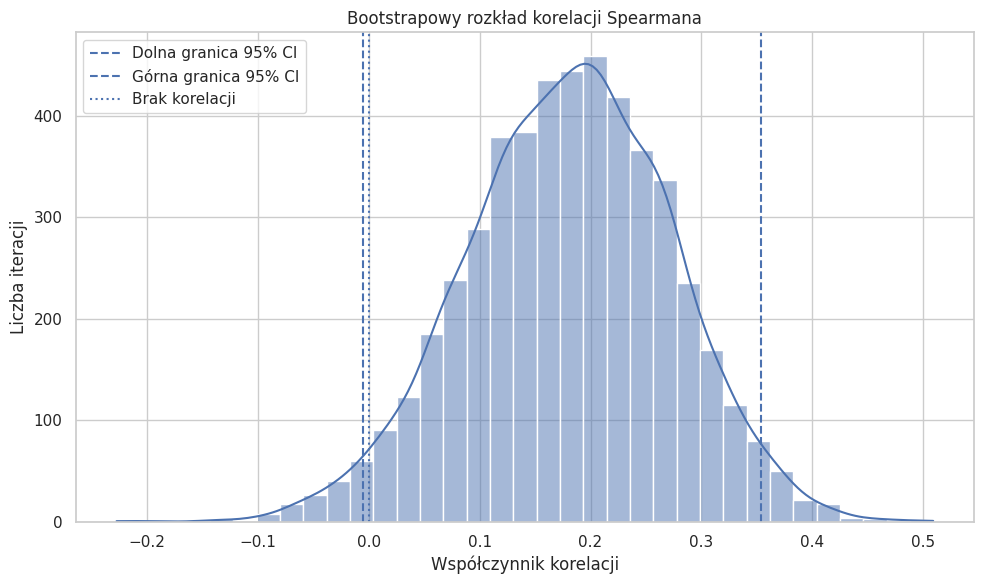

In [23]:
# Tworzy nowy obszar wykresu.
plt.figure(figsize=(10, 6))

# Rysuje histogram współczynników korelacji uzyskanych metodą bootstrap.
sns.histplot(
    rozklad_bootstrap,
    bins=35,
    kde=True,
)

# Dodaje dolną granicę przedziału ufności.
plt.axvline(
    dolna_granica,
    linestyle="--",
    label="Dolna granica 95% CI",
)

# Dodaje górną granicę przedziału ufności.
plt.axvline(
    gorna_granica,
    linestyle="--",
    label="Górna granica 95% CI",
)

# Dodaje linię oznaczającą brak korelacji.
plt.axvline(
    0,
    linestyle=":",
    label="Brak korelacji",
)

# Ustawia tytuł wykresu.
plt.title(
    f"Bootstrapowy rozkład korelacji {wynik_glowny['Metoda']}"
)

# Ustawia opis osi poziomej.
plt.xlabel("Współczynnik korelacji")

# Ustawia opis osi pionowej.
plt.ylabel("Liczba iteracji")

# Wyświetla legendę.
plt.legend()

# Dopasowuje rozmieszczenie elementów wykresu.
plt.tight_layout()

# Wyświetla wykres.
plt.show()

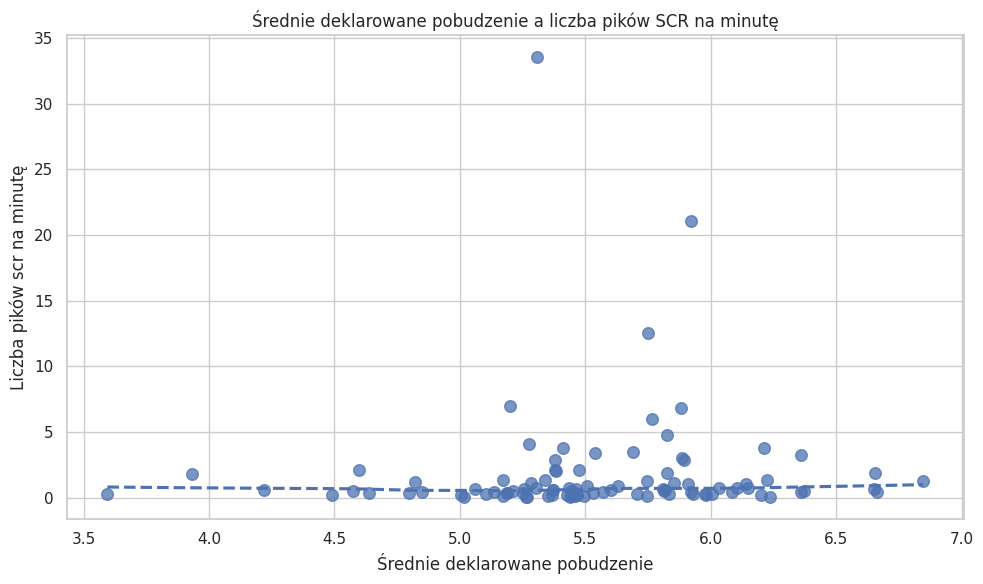

In [24]:
# Pobiera czytelną nazwę zmiennej subiektywnej.
nazwa_zmiennej_subiektywnej = NAZWY_ZMIENNYCH.get(
    ZMIENNA_SUBIEKTYWNA,
    ZMIENNA_SUBIEKTYWNA,
)

# Pobiera czytelną nazwę głównej cechy EDA.
nazwa_cechy_eda = NAZWY_ZMIENNYCH.get(
    CECHA_EDA_GLOWNA,
    CECHA_EDA_GLOWNA,
)

# Tworzy nowy obszar wykresu.
plt.figure(figsize=(10, 6))

# Sprawdza, czy zastosowano korelację Spearmana.
if wynik_glowny["Metoda"] == "Spearmana":
    # Rysuje punkty oraz nieliniową linię trendu.
    sns.regplot(
        data=dane_do_analizy_glownej,
        x=ZMIENNA_SUBIEKTYWNA,
        y=CECHA_EDA_GLOWNA,
        lowess=True,
        ci=None,
        scatter_kws={
            "s": 70,
            "alpha": 0.75,
        },
        line_kws={
            "linestyle": "--",
        },
    )

# Wykonuje się dla korelacji Pearsona.
else:
    # Rysuje punkty oraz liniową linię trendu.
    sns.regplot(
        data=dane_do_analizy_glownej,
        x=ZMIENNA_SUBIEKTYWNA,
        y=CECHA_EDA_GLOWNA,
        scatter_kws={
            "s": 70,
            "alpha": 0.75,
        },
        line_kws={
            "linestyle": "--",
        },
    )

# Ustawia tytuł wykresu.
plt.title(
    f"{nazwa_zmiennej_subiektywnej.capitalize()} "
    f"a {nazwa_cechy_eda}"
)

# Ustawia opis osi poziomej.
plt.xlabel(
    nazwa_zmiennej_subiektywnej.capitalize()
)

# Ustawia opis osi pionowej.
plt.ylabel(
    nazwa_cechy_eda.capitalize()
)

# Dopasowuje rozmieszczenie elementów wykresu.
plt.tight_layout()

# Wyświetla wykres.
plt.show()

## 10. Analiza wrażliwości na obserwacje odstające

Analizę powtarzamy po pominięciu obserwacji odstających wykrytych metodą IQR. Jeżeli kierunek i siła zależności pozostają podobne, wynik można uznać za bardziej odporny.


In [25]:
# Wykonuje główną analizę dla pełnego zbioru danych.
wynik_pelny = oblicz_korelacje(
    final_data,
    ZMIENNA_SUBIEKTYWNA,
    CECHA_EDA_GLOWNA,
    POZIOM_ISTOTNOSCI,
)

# Wyznacza obserwacje nieodstające dla zmiennej subiektywnej.
maska_x_wrazliwosc = maska_bez_odstajacych_iqr(
    final_data,
    ZMIENNA_SUBIEKTYWNA,
)

# Wyznacza obserwacje nieodstające dla głównej cechy EDA.
maska_y_wrazliwosc = maska_bez_odstajacych_iqr(
    final_data,
    CECHA_EDA_GLOWNA,
)

# Tworzy zbiór bez obserwacji odstających.
dane_bez_odstajacych_dynamiczne = final_data[
    maska_x_wrazliwosc & maska_y_wrazliwosc
].copy()

# Wykonuje analizę po usunięciu obserwacji odstających.
wynik_bez_odstajacych = oblicz_korelacje(
    dane_bez_odstajacych_dynamiczne,
    ZMIENNA_SUBIEKTYWNA,
    CECHA_EDA_GLOWNA,
    POZIOM_ISTOTNOSCI,
)

# Tworzy tabelę porównującą oba warianty analizy.
porownanie_odstajacych = pd.DataFrame([
    {
        "Wariant analizy": "Pełny zbiór",
        "Liczba obserwacji": wynik_pelny["N"],
        "Metoda": wynik_pelny["Metoda"],
        "Korelacja": wynik_pelny["Korelacja"],
        "p-value": wynik_pelny["p_value"],
    },
    {
        "Wariant analizy": "Bez obserwacji odstających",
        "Liczba obserwacji": wynik_bez_odstajacych["N"],
        "Metoda": wynik_bez_odstajacych["Metoda"],
        "Korelacja": wynik_bez_odstajacych["Korelacja"],
        "p-value": wynik_bez_odstajacych["p_value"],
    },
])

# Wyświetla porównanie wyników.
display(porownanie_odstajacych.round(4))

,Wariant analizy,Liczba obserwacji,Metoda,Korelacja,p-value
0,Pełny zbiór,95,Spearmana,0.1815,0.0784
1,Bez obserwacji odstających,77,Spearmana,0.1429,0.2151


## 11. Porównanie grup

Uczestnicy są dzieleni na liczbę grup określoną w ustawieniach projektu. Podział jest wykonywany na podstawie wartości wybranej zmiennej subiektywnej, a różnice pomiędzy grupami są oceniane dla wybranej charakterystyki EDA za pomocą testu Kruskala-Wallisa.


In [26]:
# Tworzy dane przeznaczone do analizy grupowej.
dane_grupowe = dane_do_analizy_glownej[
    [
        "ID",
        ZMIENNA_SUBIEKTYWNA,
        CECHA_EDA_GLOWNA,
    ]
].dropna().copy()

# Dzieli uczestników na grupy kwantylowe i zwraca granice przedziałów.
kody_grup, granice_grup = pd.qcut(
    # Przekazuje wybraną zmienną subiektywną.
    dane_grupowe[ZMIENNA_SUBIEKTYWNA],
    # Ustawia oczekiwaną liczbę grup.
    q=LICZBA_GRUP,
    # Zwraca numery grup zamiast gotowych etykiet.
    labels=False,
    # Zwraca również granice utworzonych przedziałów.
    retbins=True,
    # Usuwa powtarzające się granice przedziałów.
    duplicates="drop",
)

# Oblicza rzeczywistą liczbę utworzonych grup.
rzeczywista_liczba_grup = len(
    granice_grup
) - 1

# Sprawdza, czy utworzono co najmniej dwie grupy.
if rzeczywista_liczba_grup < 2:
    # Zgłasza błąd, gdy analiza grupowa nie jest możliwa.
    raise ValueError(
        "Nie udało się utworzyć co najmniej dwóch grup. "
        "Wybrana zmienna ma zbyt mało różnych wartości."
    )

# Tworzy etykiety dla dwóch grup.
if rzeczywista_liczba_grup == 2:
    # Ustawia nazwy grup niskiej i wysokiej.
    etykiety_grup = [
        "Niskie",
        "Wysokie",
    ]

# Tworzy etykiety dla trzech grup.
elif rzeczywista_liczba_grup == 3:
    # Ustawia nazwy grup niskiej, średniej i wysokiej.
    etykiety_grup = [
        "Niskie",
        "Średnie",
        "Wysokie",
    ]

# Tworzy etykiety dla czterech grup.
elif rzeczywista_liczba_grup == 4:
    # Ustawia nazwy czterech poziomów zmiennej.
    etykiety_grup = [
        "Bardzo niskie",
        "Niskie",
        "Wysokie",
        "Bardzo wysokie",
    ]

# Wykonuje się dla innej liczby grup.
else:
    # Tworzy automatyczne nazwy grup.
    etykiety_grup = [
        f"Grupa {numer}"
        for numer in range(
            1,
            rzeczywista_liczba_grup + 1,
        )
    ]

# Przypisuje uczestników do odpowiednich grup.
dane_grupowe["Grupa_badawcza"] = pd.Categorical.from_codes(
    # Przekazuje numery grup.
    kody_grup.astype(int),
    # Przekazuje przygotowane etykiety grup.
    categories=etykiety_grup,
    # Zachowuje kolejność grup.
    ordered=True,
)

# Tworzy tabelę podsumowującą grupy.
podsumowanie_grup = (
    # Rozpoczyna operację na danych grupowych.
    dane_grupowe
    # Grupuje uczestników według przypisanej grupy.
    .groupby(
        "Grupa_badawcza",
        observed=True,
    )
    # Oblicza statystyki wybranej charakterystyki EDA.
    .agg(
        # Zlicza uczestników w każdej grupie.
        Liczba_osob=("ID", "count"),
        # Oblicza średnią wartość cechy EDA.
        Srednia_cechy=(CECHA_EDA_GLOWNA, "mean"),
        # Oblicza medianę wartości cechy EDA.
        Mediana_cechy=(CECHA_EDA_GLOWNA, "median"),
        # Oblicza odchylenie standardowe cechy EDA.
        Odchylenie_standardowe=(CECHA_EDA_GLOWNA, "std"),
    )
    # Zamienia indeks grup na zwykłą kolumnę.
    .reset_index()
)

# Wyświetla tabelę podsumowującą grupy.
display(podsumowanie_grup.round(4))


,Grupa_badawcza,Liczba_osob,Srednia_cechy,Mediana_cechy,Odchylenie_standardowe
0,Niskie,32,1.9012,0.3850,5.9343
1,Średnie,31,1.5448,0.5913,2.4736
2,Wysokie,32,1.9544,0.7203,3.8129


In [27]:
# Przygotowuje osobne zbiory wartości dla kolejnych grup.
grupy = [
    # Pobiera wartości wybranej charakterystyki EDA i usuwa braki.
    grupa[CECHA_EDA_GLOWNA].dropna().values
    # Powtarza operację dla każdej grupy badawczej.
    for _, grupa in dane_grupowe.groupby(
        "Grupa_badawcza",
        observed=True,
    )
]

# Sprawdza, czy każda grupa zawiera przynajmniej jedną obserwację.
if any(len(grupa) == 0 for grupa in grupy):
    # Zgłasza błąd dla pustej grupy.
    raise ValueError(
        "Co najmniej jedna grupa nie zawiera obserwacji."
    )

# Wykonuje test Kruskala-Wallisa.
statystyka_kw, p_kw = stats.kruskal(
    *grupy
)

# Wyświetla wartość statystyki testowej.
print(
    "Statystyka testu Kruskala-Wallisa: "
    f"{statystyka_kw:.3f}"
)

# Wyświetla wartość p.
print(f"P-value: {p_kw:.4f}")

# Sprawdza istotność statystyczną różnic pomiędzy grupami.
if p_kw < POZIOM_ISTOTNOSCI:
    # Wyświetla interpretację istotnego wyniku.
    print(
        "Pomiędzy grupami występują istotne statystycznie różnice."
    )

# Wykonuje się dla wyniku nieistotnego statystycznie.
else:
    # Wyświetla interpretację braku istotnych różnic.
    print(
        "Nie wykazano istotnych statystycznie różnic pomiędzy grupami."
    )


Statystyka testu Kruskala-Wallisa: 3.347
P-value: 0.1876
Nie wykazano istotnych statystycznie różnic pomiędzy grupami.


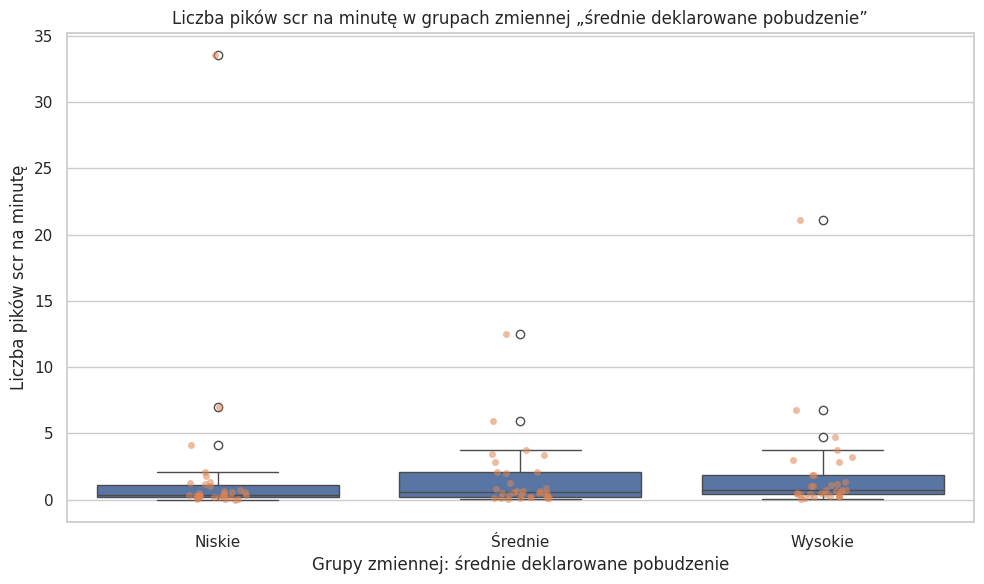

In [28]:
# Pobiera czytelną nazwę wybranej zmiennej subiektywnej.
nazwa_zmiennej_grupujacej = NAZWY_ZMIENNYCH.get(
    ZMIENNA_SUBIEKTYWNA,
    ZMIENNA_SUBIEKTYWNA,
)

# Pobiera czytelną nazwę wybranej charakterystyki EDA.
nazwa_cechy_grupowej = NAZWY_ZMIENNYCH.get(
    CECHA_EDA_GLOWNA,
    CECHA_EDA_GLOWNA,
)

# Tworzy nowy obszar wykresu.
plt.figure(figsize=(10, 6))

# Rysuje wykres pudełkowy dla grup badawczych.
sns.boxplot(
    # Przekazuje dane grupowe.
    data=dane_grupowe,
    # Ustawia grupy badawcze na osi poziomej.
    x="Grupa_badawcza",
    # Ustawia wybraną charakterystykę EDA na osi pionowej.
    y=CECHA_EDA_GLOWNA,
)

# Dodaje pojedyncze obserwacje uczestników.
sns.stripplot(
    # Przekazuje dane grupowe.
    data=dane_grupowe,
    # Ustawia grupy badawcze na osi poziomej.
    x="Grupa_badawcza",
    # Ustawia wybraną charakterystykę EDA na osi pionowej.
    y=CECHA_EDA_GLOWNA,
    # Ustawia częściową przezroczystość punktów.
    alpha=0.55,
)

# Ustawia tytuł wykresu.
plt.title(
    f"{nazwa_cechy_grupowej.capitalize()} w grupach zmiennej "
    f"„{nazwa_zmiennej_grupujacej}”"
)

# Ustawia opis osi poziomej.
plt.xlabel(
    f"Grupy zmiennej: {nazwa_zmiennej_grupujacej}"
)

# Ustawia opis osi pionowej.
plt.ylabel(
    nazwa_cechy_grupowej.capitalize()
)

# Dopasowuje rozmieszczenie elementów wykresu.
plt.tight_layout()

# Wyświetla wykres.
plt.show()


## 12. Korelacje z dodatkowymi charakterystykami EDA

Wybrana zmienna subiektywna jest porównywana z pozostałymi dostępnymi charakterystykami EDA. Główna cecha EDA wybrana w ustawieniach projektu jest pomijana w tej części, ponieważ została już oceniona w analizie podstawowej.

Ze względu na wykonywanie wielu testów jednocześnie stosowana jest korekta Benjamini-Hochberga.


In [29]:
# Tworzy listę dodatkowych charakterystyk EDA.
cechy_eda_do_testow = [
    # Wybiera cechy dostępne w danych końcowych i różne od cechy głównej.
    cecha
    for cecha in DOSTEPNE_CECHY_EDA
    if (
        cecha in final_data.columns
        and cecha != CECHA_EDA_GLOWNA
    )
]

# Tworzy pustą listę na wyniki korelacji.
wyniki_cech = []

# Analizuje każdą dodatkową charakterystykę EDA.
for cecha in cechy_eda_do_testow:
    # Wybiera kompletne obserwacje obu zmiennych.
    para = dane_do_analizy_glownej[
        [ZMIENNA_SUBIEKTYWNA, cecha]
    ].dropna()

    # Pomija analizę przy zbyt małej liczbie obserwacji.
    if len(para) < 3:
        # Przechodzi do kolejnej charakterystyki.
        continue

    # Oblicza korelację Spearmana i wartość p.
    korelacja, p_value = stats.spearmanr(
        para[ZMIENNA_SUBIEKTYWNA],
        para[cecha],
    )

    # Dodaje wynik do listy.
    wyniki_cech.append({
        # Zapisuje techniczną nazwę charakterystyki EDA.
        "Cecha_EDA": cecha,
        # Zapisuje czytelną nazwę charakterystyki EDA.
        "Nazwa_cechy": NAZWY_ZMIENNYCH.get(
            cecha,
            cecha,
        ),
        # Zapisuje liczbę wykorzystanych obserwacji.
        "N": len(para),
        # Zapisuje współczynnik korelacji Spearmana.
        "Spearman_rho": korelacja,
        # Zapisuje wartość p.
        "p_value": p_value,
    })

# Tworzy tabelę wyników dodatkowych korelacji.
tabela_cech = pd.DataFrame(wyniki_cech)

# Sprawdza, czy wykonano co najmniej jeden test.
if not tabela_cech.empty:
    # Oblicza wartości p po korekcie FDR.
    tabela_cech["p_value_FDR"] = multipletests(
        tabela_cech["p_value"],
        method="fdr_bh",
    )[1]

    # Oznacza wyniki istotne po korekcie FDR.
    tabela_cech["Istotne_po_FDR"] = (
        tabela_cech["p_value_FDR"]
        < POZIOM_ISTOTNOSCI
    )

    # Sortuje wyniki według poprawionej wartości p.
    tabela_cech = tabela_cech.sort_values(
        "p_value_FDR"
    )

# Wyświetla tabelę dodatkowych korelacji.
display(tabela_cech.round(4))


,Cecha_EDA,Nazwa_cechy,N,Spearman_rho,p_value,p_value_FDR,Istotne_po_FDR
0,SCR_Amplitude_Mean,średnia amplituda pików SCR,95,-0.1623,0.1160,0.5428,False
1,SCR_Amplitude_Median,mediana amplitudy pików SCR,95,-0.1236,0.2326,0.5428,False
2,SCR_Amplitude_Max,maksymalna amplituda pików SCR,95,-0.1434,0.1655,0.5428,False
5,EDA_Phasic_Mean,średni poziom składowej fazowej EDA,95,0.0859,0.4080,0.7141,False
3,EDA_Tonic_Mean,średni poziom składowej tonicznej EDA,95,-0.0598,0.5649,0.7909,False
4,EDA_Tonic_SD,zmienność składowej tonicznej EDA,95,-0.0237,0.8194,0.8194,False
6,EDA_Phasic_SD,zmienność składowej fazowej EDA,95,-0.0372,0.7204,0.8194,False


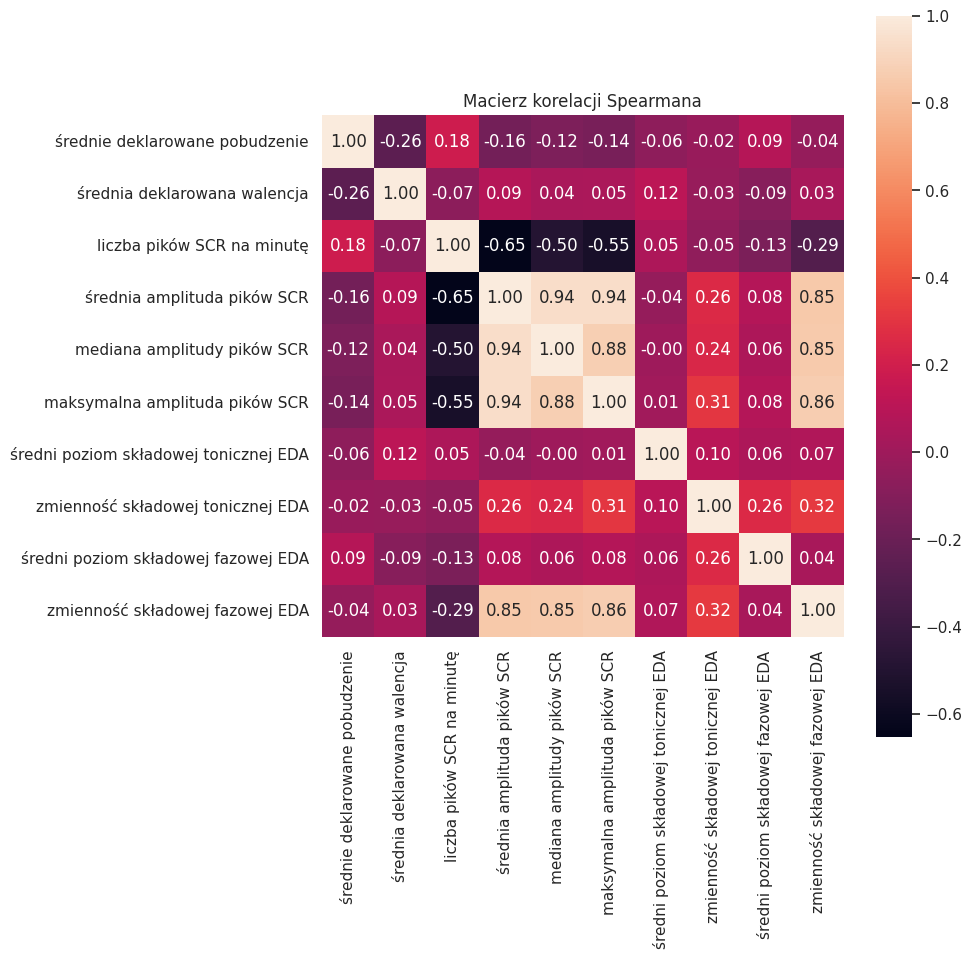

In [30]:
# Tworzy listę zmiennych uwzględnianych w macierzy korelacji.
zmienne_macierzy = [
    # Dodaje wybraną zmienną subiektywną.
    ZMIENNA_SUBIEKTYWNA,
    # Dodaje drugą dostępną zmienną subiektywną.
    "Mean_Arousal",
    # Dodaje drugą dostępną zmienną subiektywną.
    "Mean_Valence",
    # Dodaje wybraną główną charakterystykę EDA.
    CECHA_EDA_GLOWNA,
    # Dodaje wszystkie pozostałe charakterystyki EDA.
    *DOSTEPNE_CECHY_EDA,
]

# Usuwa powtarzające się nazwy zmiennych.
zmienne_macierzy = list(
    dict.fromkeys(zmienne_macierzy)
)

# Pozostawia wyłącznie zmienne dostępne w danych końcowych.
zmienne_macierzy = [
    zmienna
    for zmienna in zmienne_macierzy
    if zmienna in final_data.columns
]

# Oblicza macierz korelacji rang Spearmana.
macierz_korelacji = final_data[
    zmienne_macierzy
].corr(method="spearman")

# Zamienia techniczne nazwy kolumn na czytelne nazwy.
macierz_korelacji = macierz_korelacji.rename(
    index=NAZWY_ZMIENNYCH,
    columns=NAZWY_ZMIENNYCH,
)

# Ustala rozmiar wykresu zależnie od liczby zmiennych.
rozmiar_wykresu = max(
    10,
    len(zmienne_macierzy),
)

# Tworzy obszar mapy cieplnej.
plt.figure(
    figsize=(rozmiar_wykresu, rozmiar_wykresu)
)

# Rysuje mapę cieplną macierzy korelacji.
sns.heatmap(
    # Przekazuje macierz korelacji.
    macierz_korelacji,
    # Wyświetla wartości współczynników w komórkach.
    annot=True,
    # Ustawia dokładność wartości do dwóch miejsc po przecinku.
    fmt=".2f",
    # Ustawia kwadratowy kształt komórek.
    square=True,
)

# Ustawia tytuł wykresu.
plt.title("Macierz korelacji Spearmana")

# Dopasowuje rozmieszczenie elementów wykresu.
plt.tight_layout()

# Wyświetla wykres.
plt.show()


## 13. Analiza eksploracyjna cech osobowości

Analiza eksploracyjna sprawdza związki cech osobowości z wybraną zmienną subiektywną oraz z wybraną główną charakterystyką EDA. Ze względu na wykonywanie wielu testów stosowana jest korekta Benjamini-Hochberga.


In [31]:
# Tworzy listę analizowanych cech osobowości.
kolumny_osobowosci = [
    # Dodaje otwartość na doświadczenie.
    "OPENNESS",
    # Dodaje sumienność.
    "CONSCIENTIOUSNESS",
    # Dodaje neurotyczność.
    "NEUROTICISM",
    # Dodaje ugodowość.
    "AGREEABLENESS",
    # Dodaje ekstrawersję.
    "EXTRAVERSION",
]

# Pozostawia wyłącznie cechy dostępne w danych procedury.
kolumny_osobowosci = [
    kolumna
    for kolumna in kolumny_osobowosci
    if kolumna in procedure.columns
]

# Tworzy tabelę cech osobowości na poziomie uczestnika.
osobowosc = (
    # Wybiera identyfikator i dostępne cechy osobowości.
    procedure[["ID"] + kolumny_osobowosci]
    # Usuwa powtarzające się rekordy tego samego uczestnika.
    .drop_duplicates(subset="ID")
    # Tworzy niezależną kopię tabeli.
    .copy()
)

# Zamienia identyfikator uczestnika na tekst.
osobowosc["ID"] = (
    osobowosc["ID"]
    .astype(int)
    .astype(str)
)

# Łączy dane końcowe z cechami osobowości.
dane_rozszerzone = pd.merge(
    # Przekazuje dane końcowe.
    final_data,
    # Przekazuje tabelę cech osobowości.
    osobowosc,
    # Łączy tabele na podstawie identyfikatora uczestnika.
    on="ID",
    # Zachowuje wszystkich uczestników z danych końcowych.
    how="left",
    # Sprawdza relację jeden do jednego.
    validate="one_to_one",
)

# Tworzy listę zmiennych zależnych analizowanych z osobowością.
zmienne_zalezne_osobowosc = [
    # Dodaje wybraną zmienną subiektywną.
    ZMIENNA_SUBIEKTYWNA,
    # Dodaje wybraną główną charakterystykę EDA.
    CECHA_EDA_GLOWNA,
]

# Usuwa ewentualne powtórzenia nazw zmiennych zależnych.
zmienne_zalezne_osobowosc = list(
    dict.fromkeys(zmienne_zalezne_osobowosc)
)

# Tworzy pustą listę na wyniki analizy osobowości.
wyniki_osobowosci = []

# Analizuje każdą dostępną cechę osobowości.
for cecha in kolumny_osobowosci:
    # Analizuje każdą wybraną zmienną zależną.
    for zmienna_zalezna in zmienne_zalezne_osobowosc:
        # Wybiera kompletne obserwacje obu zmiennych.
        para = dane_rozszerzone[
            [cecha, zmienna_zalezna]
        ].dropna()

        # Pomija analizę przy zbyt małej liczbie obserwacji.
        if len(para) < 3:
            # Przechodzi do kolejnej pary zmiennych.
            continue

        # Oblicza korelację Spearmana i wartość p.
        rho, p_value = stats.spearmanr(
            para[cecha],
            para[zmienna_zalezna],
        )

        # Dodaje wynik do listy.
        wyniki_osobowosci.append({
            # Zapisuje nazwę cechy osobowości.
            "Cecha_osobowosci": cecha,
            # Zapisuje techniczną nazwę zmiennej zależnej.
            "Zmienna": zmienna_zalezna,
            # Zapisuje czytelną nazwę zmiennej zależnej.
            "Nazwa_zmiennej": NAZWY_ZMIENNYCH.get(
                zmienna_zalezna,
                zmienna_zalezna,
            ),
            # Zapisuje liczbę obserwacji.
            "N": len(para),
            # Zapisuje współczynnik korelacji Spearmana.
            "Spearman_rho": rho,
            # Zapisuje wartość p.
            "p_value": p_value,
        })

# Tworzy tabelę wyników analizy osobowości.
tabela_osobowosci = pd.DataFrame(
    wyniki_osobowosci
)

# Sprawdza, czy wykonano co najmniej jeden test.
if not tabela_osobowosci.empty:
    # Oblicza wartości p po korekcie FDR.
    tabela_osobowosci["p_value_FDR"] = multipletests(
        tabela_osobowosci["p_value"],
        method="fdr_bh",
    )[1]

    # Oznacza wyniki istotne po korekcie FDR.
    tabela_osobowosci["Istotne_po_FDR"] = (
        tabela_osobowosci["p_value_FDR"]
        < POZIOM_ISTOTNOSCI
    )

    # Sortuje wyniki według poprawionej wartości p.
    tabela_osobowosci = tabela_osobowosci.sort_values(
        "p_value_FDR"
    )

# Wyświetla tabelę wyników analizy osobowości.
display(tabela_osobowosci.round(4))


,Cecha_osobowosci,Zmienna,Nazwa_zmiennej,N,Spearman_rho,p_value,p_value_FDR,Istotne_po_FDR
5,NEUROTICISM,EDA_Peaks_Per_Min,liczba pików SCR na minutę,95,0.2118,0.0393,0.3933,False
4,NEUROTICISM,Mean_Arousal,średnie deklarowane pobudzenie,95,0.1300,0.2091,0.6970,False
9,EXTRAVERSION,EDA_Peaks_Per_Min,liczba pików SCR na minutę,95,-0.1526,0.1397,0.6970,False
8,EXTRAVERSION,Mean_Arousal,średnie deklarowane pobudzenie,95,-0.1076,0.2993,0.7483,False
6,AGREEABLENESS,Mean_Arousal,średnie deklarowane pobudzenie,95,-0.0644,0.5354,0.7593,False
2,CONSCIENTIOUSNESS,Mean_Arousal,średnie deklarowane pobudzenie,95,0.0627,0.5459,0.7593,False
0,OPENNESS,Mean_Arousal,średnie deklarowane pobudzenie,95,0.0534,0.6075,0.7593,False
1,OPENNESS,EDA_Peaks_Per_Min,liczba pików SCR na minutę,95,-0.0749,0.4705,0.7593,False
7,AGREEABLENESS,EDA_Peaks_Per_Min,liczba pików SCR na minutę,95,-0.0416,0.6889,0.7654,False
3,CONSCIENTIOUSNESS,EDA_Peaks_Per_Min,liczba pików SCR na minutę,95,0.0020,0.9847,0.9847,False


## 14. Interpretacja głównego wyniku

Sekcja przedstawia syntetyczną interpretację głównej analizy korelacji, jej istotności statystycznej oraz bootstrapowego przedziału ufności.


In [32]:
# Importuje klasę służącą do estetycznego wyświetlania tekstu.
from IPython.display import Markdown

# Pobiera współczynnik głównej korelacji.
korelacja = wynik_glowny["Korelacja"]

# Pobiera wartość p głównej korelacji.
p_value = wynik_glowny["p_value"]

# Pobiera nazwę zastosowanej metody.
metoda = wynik_glowny["Metoda"]

# Pobiera liczbę analizowanych uczestników.
liczba_osob = wynik_glowny["N"]

# Oblicza wartość bezwzględną współczynnika korelacji.
wartosc_bezwzgledna = abs(korelacja)

# Określa siłę zaobserwowanej zależności.
if wartosc_bezwzgledna < 0.10:
    # Zapisuje opis bardzo słabej zależności.
    sila = "bardzo słaba"

elif wartosc_bezwzgledna < 0.30:
    # Zapisuje opis słabej zależności.
    sila = "słaba"

elif wartosc_bezwzgledna < 0.50:
    # Zapisuje opis umiarkowanej zależności.
    sila = "umiarkowana"

elif wartosc_bezwzgledna < 0.70:
    # Zapisuje opis silnej zależności.
    sila = "silna"

else:
    # Zapisuje opis bardzo silnej zależności.
    sila = "bardzo silna"

# Określa kierunek zaobserwowanej zależności.
if korelacja > 0:
    # Zapisuje dodatni kierunek zależności.
    kierunek = "dodatnia"

elif korelacja < 0:
    # Zapisuje ujemny kierunek zależności.
    kierunek = "ujemna"

else:
    # Zapisuje brak kierunku zależności.
    kierunek = "zerowa"

# Sprawdza istotność statystyczną wyniku.
if p_value < POZIOM_ISTOTNOSCI:
    # Tworzy interpretację istotnego wyniku.
    decyzja = (
        "Wynik jest istotny statystycznie. "
        "Hipoteza zerowa została odrzucona."
    )

else:
    # Tworzy interpretację nieistotnego wyniku.
    decyzja = (
        "Wynik nie jest istotny statystycznie. "
        "Nie ma podstaw do odrzucenia hipotezy zerowej."
    )

# Sprawdza, czy przedział ufności obejmuje wartość zero.
if dolna_granica <= 0 <= gorna_granica:
    # Tworzy interpretację przedziału obejmującego zero.
    interpretacja_przedzialu = (
        "Przedział ufności obejmuje wartość zero, "
        "co jest zgodne z brakiem istotnej zależności."
    )

else:
    # Tworzy interpretację przedziału nieobejmującego zera.
    interpretacja_przedzialu = (
        "Przedział ufności nie obejmuje wartości zero, "
        "co wskazuje na stabilny kierunek zależności."
    )

# Pobiera czytelną nazwę zmiennej subiektywnej.
nazwa_x = NAZWY_ZMIENNYCH.get(
    ZMIENNA_SUBIEKTYWNA,
    ZMIENNA_SUBIEKTYWNA,
)

# Pobiera czytelną nazwę głównej cechy EDA.
nazwa_y = NAZWY_ZMIENNYCH.get(
    CECHA_EDA_GLOWNA,
    CECHA_EDA_GLOWNA,
)

# Tworzy tekst interpretacji głównego wyniku.
interpretacja_glowna = f"""
### Interpretacja głównego wyniku

Analizę przeprowadzono dla **{liczba_osob} uczestników**. Badano zależność pomiędzy zmienną **„{nazwa_x}”** a charakterystyką EDA **„{nazwa_y}”**.

Na podstawie rozkładów danych zastosowano współczynnik korelacji **{metoda}**. Zaobserwowana zależność była **{sila} i {kierunek}**. Współczynnik korelacji wyniósł **r = {korelacja:.3f}**, a wartość istotności statystycznej wyniosła **p = {p_value:.4f}**.

{decyzja}

Bootstrapowy 95-procentowy przedział ufności wyniósł **[{dolna_granica:.3f}, {gorna_granica:.3f}]**. {interpretacja_przedzialu}
"""

# Wyświetla interpretację głównego wyniku.
display(Markdown(interpretacja_glowna))


### Interpretacja głównego wyniku

Analizę przeprowadzono dla **95 uczestników**. Badano zależność pomiędzy zmienną **„średnie deklarowane pobudzenie”** a charakterystyką EDA **„liczba pików SCR na minutę”**.

Na podstawie rozkładów danych zastosowano współczynnik korelacji **Spearmana**. Zaobserwowana zależność była **słaba i dodatnia**. Współczynnik korelacji wyniósł **r = 0.181**, a wartość istotności statystycznej wyniosła **p = 0.0784**.

Wynik nie jest istotny statystycznie. Nie ma podstaw do odrzucenia hipotezy zerowej.

Bootstrapowy 95-procentowy przedział ufności wyniósł **[-0.005, 0.353]**. Przedział ufności obejmuje wartość zero, co jest zgodne z brakiem istotnej zależności.


## 15. Podsumowanie wyników i wnioski końcowe

Sekcja łączy wyniki analizy głównej, porównania grup, analiz dodatkowych oraz oceny odporności wyniku. Na tej podstawie formułowane są wnioski końcowe i ograniczenia przeprowadzonego badania.


In [33]:
# Importuje klasę do estetycznego wyświetlania podsumowania.
from IPython.display import Markdown

# Definiuje funkcję formatującą liczby z przecinkiem dziesiętnym.
def formatuj_liczbe(
    wartosc,
    liczba_miejsc=3,
):
    # Zwraca wartość w polskim formacie dziesiętnym.
    return f"{wartosc:.{liczba_miejsc}f}".replace(".", ",")


# Pobiera czytelną nazwę zmiennej subiektywnej.
nazwa_x = NAZWY_ZMIENNYCH.get(
    ZMIENNA_SUBIEKTYWNA,
    ZMIENNA_SUBIEKTYWNA,
)

# Pobiera czytelną nazwę głównej cechy EDA.
nazwa_y = NAZWY_ZMIENNYCH.get(
    CECHA_EDA_GLOWNA,
    CECHA_EDA_GLOWNA,
)

# Tworzy dane wykorzystywane w analizie grupowej.
dane_podsumowania = dane_do_analizy_glownej[
    [
        "ID",
        ZMIENNA_SUBIEKTYWNA,
        CECHA_EDA_GLOWNA,
    ]
].dropna().copy()

# Dzieli zmienną subiektywną na grupy kwantylowe.
numery_grup, granice_grup = pd.qcut(
    dane_podsumowania[ZMIENNA_SUBIEKTYWNA],
    q=LICZBA_GRUP,
    labels=False,
    retbins=True,
    duplicates="drop",
)

# Oblicza rzeczywistą liczbę utworzonych grup.
rzeczywista_liczba_grup = len(
    granice_grup
) - 1

# Tworzy nazwy dla dwóch grup.
if rzeczywista_liczba_grup == 2:
    # Ustawia etykiety grup.
    etykiety_podsumowania = [
        "Niskie",
        "Wysokie",
    ]

# Tworzy nazwy dla trzech grup.
elif rzeczywista_liczba_grup == 3:
    # Ustawia etykiety grup.
    etykiety_podsumowania = [
        "Niskie",
        "Średnie",
        "Wysokie",
    ]

# Tworzy nazwy dla czterech grup.
elif rzeczywista_liczba_grup == 4:
    # Ustawia etykiety grup.
    etykiety_podsumowania = [
        "Bardzo niskie",
        "Niskie",
        "Wysokie",
        "Bardzo wysokie",
    ]

# Wykonuje się dla innej liczby grup.
else:
    # Tworzy automatyczne nazwy grup.
    etykiety_podsumowania = [
        f"Grupa {numer}"
        for numer in range(
            1,
            rzeczywista_liczba_grup + 1,
        )
    ]

# Przypisuje uczestników do odpowiednich grup.
dane_podsumowania["Grupa"] = pd.Categorical.from_codes(
    numery_grup.astype(int),
    categories=etykiety_podsumowania,
    ordered=True,
)

# Przygotowuje wartości głównej cechy EDA dla każdej grupy.
grupy_podsumowania = [
    grupa[CECHA_EDA_GLOWNA].dropna().values
    for _, grupa in dane_podsumowania.groupby(
        "Grupa",
        observed=True,
    )
]

# Wykonuje test Kruskala-Wallisa.
h_kruskal_podsumowanie, p_kruskal_podsumowanie = stats.kruskal(
    *grupy_podsumowania
)

# Sprawdza wynik testu Kruskala-Wallisa.
if p_kruskal_podsumowanie < POZIOM_ISTOTNOSCI:
    # Tworzy interpretację istotnych różnic.
    interpretacja_grup = (
        "Pomiędzy grupami wystąpiły istotne statystycznie różnice."
    )

else:
    # Tworzy interpretację braku istotnych różnic.
    interpretacja_grup = (
        "Pomiędzy grupami nie wykazano istotnych statystycznie różnic."
    )

# Tworzy listę dodatkowych charakterystyk EDA.
cechy_eda_podsumowanie = DOSTEPNE_CECHY_EDA.copy()

# Usuwa z listy główną cechę analizowaną wcześniej.
cechy_eda_podsumowanie = [
    cecha
    for cecha in cechy_eda_podsumowanie
    if (
        cecha in final_data.columns
        and cecha != CECHA_EDA_GLOWNA
    )
]

# Tworzy pustą listę na wyniki dodatkowych korelacji.
wyniki_eda_podsumowanie = []

# Analizuje kolejne charakterystyki EDA.
for cecha in cechy_eda_podsumowanie:
    # Wybiera kompletne obserwacje.
    para = dane_do_analizy_glownej[
        [ZMIENNA_SUBIEKTYWNA, cecha]
    ].dropna()

    # Pomija analizę przy zbyt małej liczbie obserwacji.
    if len(para) < 3:
        # Przechodzi do kolejnej cechy.
        continue

    # Oblicza korelację Spearmana.
    rho, p_value_cechy = stats.spearmanr(
        para[ZMIENNA_SUBIEKTYWNA],
        para[cecha],
    )

    # Dodaje wynik do listy.
    wyniki_eda_podsumowanie.append({
        "Cecha": cecha,
        "Korelacja": rho,
        "p_value": p_value_cechy,
    })

# Tworzy tabelę dodatkowych charakterystyk EDA.
tabela_eda_podsumowanie = pd.DataFrame(
    wyniki_eda_podsumowanie
)

# Sprawdza, czy tabela zawiera wyniki.
if not tabela_eda_podsumowanie.empty:
    # Oblicza wartości p po korekcie FDR.
    tabela_eda_podsumowanie["p_value_FDR"] = multipletests(
        tabela_eda_podsumowanie["p_value"],
        method="fdr_bh",
    )[1]

    # Oznacza wyniki istotne statystycznie.
    tabela_eda_podsumowanie["Istotna_po_FDR"] = (
        tabela_eda_podsumowanie["p_value_FDR"]
        < POZIOM_ISTOTNOSCI
    )

    # Wybiera cechy istotne po korekcie FDR.
    istotne_cechy_eda = tabela_eda_podsumowanie[
        tabela_eda_podsumowanie["Istotna_po_FDR"]
    ]

    # Sprawdza, czy znaleziono istotne charakterystyki.
    if istotne_cechy_eda.empty:
        # Tworzy interpretację braku istotnych wyników.
        interpretacja_eda = (
            "Po zastosowaniu korekty FDR żadna z dodatkowych "
            "charakterystyk EDA nie wykazała istotnej zależności."
        )

    else:
        # Pobiera czytelne nazwy istotnych charakterystyk.
        nazwy_istotnych_cech = [
            NAZWY_ZMIENNYCH.get(
                cecha,
                cecha,
            )
            for cecha in istotne_cechy_eda["Cecha"]
        ]

        # Łączy nazwy charakterystyk w jeden tekst.
        tekst_istotnych_cech = ", ".join(
            nazwy_istotnych_cech
        )

        # Tworzy interpretację istotnych wyników.
        interpretacja_eda = (
            "Po zastosowaniu korekty FDR istotne zależności "
            f"wykazały: {tekst_istotnych_cech}."
        )

# Wykonuje się, gdy nie przeprowadzono dodatkowych analiz.
else:
    # Tworzy odpowiednią informację.
    interpretacja_eda = (
        "Nie przeprowadzono dodatkowych analiz charakterystyk EDA."
    )

# Oblicza różnicę pomiędzy korelacją pełną i korelacją bez obserwacji odstających.
roznica_korelacji = abs(
    wynik_pelny["Korelacja"]
    - wynik_bez_odstajacych["Korelacja"]
)

# Sprawdza zgodność kierunku obu korelacji.
zgodny_kierunek = (
    np.sign(wynik_pelny["Korelacja"])
    == np.sign(wynik_bez_odstajacych["Korelacja"])
)

# Ocenia odporność głównego wyniku.
if (
    zgodny_kierunek
    and roznica_korelacji < 0.10
):
    # Tworzy interpretację stabilnego wyniku.
    interpretacja_wrazliwosci = (
        "Po usunięciu obserwacji odstających kierunek i siła "
        "zależności pozostały zbliżone. Wynik można uznać "
        "za odporny na pojedyncze wartości skrajne."
    )

else:
    # Tworzy interpretację niestabilnego wyniku.
    interpretacja_wrazliwosci = (
        "Usunięcie obserwacji odstających zauważalnie zmieniło "
        "wynik, dlatego interpretacja zależności wymaga ostrożności."
    )

# Sprawdza, czy główna zależność jest istotna statystycznie.
if wynik_glowny["p_value"] < POZIOM_ISTOTNOSCI:
    # Sprawdza, czy zależność ma kierunek dodatni.
    if wynik_glowny["Korelacja"] > 0:
        # Tworzy końcowy wniosek zgodny z hipotezą badawczą.
        wniosek_koncowy = (
            "Uzyskane wyniki potwierdzają hipotezę o dodatnim "
            "związku pomiędzy badanymi zmiennymi."
        )

    # Wykonuje się dla istotnej zależności ujemnej.
    else:
        # Tworzy końcowy wniosek o przeciwnym kierunku zależności.
        wniosek_koncowy = (
            "Wykazano istotną zależność, jednak jej kierunek był "
            "przeciwny do kierunku założonego w hipotezie badawczej."
        )

# Wykonuje się dla wyniku nieistotnego statystycznie.
else:
    # Tworzy końcowy wniosek o braku potwierdzenia hipotezy.
    wniosek_koncowy = (
        "Uzyskane wyniki nie potwierdzają hipotezy o istotnym "
        "związku pomiędzy badanymi zmiennymi."
    )

# Tworzy tabelę najważniejszych wyników liczbowych.
podsumowanie_liczbowe = pd.DataFrame({
    "Parametr": [
        "Liczba uczestników",
        "Zmienna subiektywna",
        "Główna cecha EDA",
        "Metoda korelacji",
        "Współczynnik korelacji",
        "p-value korelacji",
        "Dolna granica 95% CI",
        "Górna granica 95% CI",
        "Liczba grup",
        "Statystyka Kruskala-Wallisa H",
        "p-value Kruskala-Wallisa",
    ],
    "Wartość": [
        str(wynik_glowny["N"]),
        nazwa_x,
        nazwa_y,
        wynik_glowny["Metoda"],
        formatuj_liczbe(
            wynik_glowny["Korelacja"],
            3,
        ),
        formatuj_liczbe(
            wynik_glowny["p_value"],
            4,
        ),
        formatuj_liczbe(
            dolna_granica,
            3,
        ),
        formatuj_liczbe(
            gorna_granica,
            3,
        ),
        str(rzeczywista_liczba_grup),
        formatuj_liczbe(
            h_kruskal_podsumowanie,
            3,
        ),
        formatuj_liczbe(
            p_kruskal_podsumowanie,
            4,
        ),
    ],
})

# Wyświetla tabelę najważniejszych wyników.
display(podsumowanie_liczbowe)

# Tworzy pełne podsumowanie projektu.
podsumowanie_analizy = f"""
## Podsumowanie analizy

### 1. Cel i zakres analizy

Analizę przeprowadzono dla **{wynik_glowny["N"]} uczestników**. Jej celem było sprawdzenie zależności pomiędzy zmienną **„{nazwa_x}”** a charakterystyką sygnału EDA **„{nazwa_y}”**.

### 2. Główny wynik statystyczny

Na podstawie analizy normalności rozkładów zastosowano współczynnik korelacji **{wynik_glowny["Metoda"]}**. Współczynnik korelacji wyniósł **r = {formatuj_liczbe(wynik_glowny["Korelacja"], 3)}**, natomiast poziom istotności wyniósł **p = {formatuj_liczbe(wynik_glowny["p_value"], 4)}**.

Bootstrapowy 95-procentowy przedział ufności wyniósł **[{formatuj_liczbe(dolna_granica, 3)}, {formatuj_liczbe(gorna_granica, 3)}]**.

### 3. Porównanie grup

Uczestników podzielono na **{rzeczywista_liczba_grup} grupy** na podstawie wartości zmiennej „{nazwa_x}”. Test Kruskala-Wallisa dał wynik **H = {formatuj_liczbe(h_kruskal_podsumowanie, 3)}**, **p = {formatuj_liczbe(p_kruskal_podsumowanie, 4)}**. {interpretacja_grup}

### 4. Dodatkowe charakterystyki EDA

{interpretacja_eda}

### 5. Analiza odporności wyniku

{interpretacja_wrazliwosci}

### 6. Wniosek końcowy

{wniosek_koncowy}

### 7. Ograniczenia analizy

Korelacja nie pozwala na stwierdzenie związku przyczynowego. Na wyniki mogły wpływać indywidualne różnice fizjologiczne, jakość kontaktu elektrod ze skórą, ruch uczestników, długość nagrania oraz parametry algorytmu wykrywającego reakcje SCR. Deklarowane oceny emocji miały charakter subiektywny, a agregacja wyników do jednej wartości dla każdego uczestnika ograniczyła możliwość analizy zmian zachodzących w czasie.
"""

# Wyświetla pełne podsumowanie projektu.
display(Markdown(podsumowanie_analizy))

# Ustawia ścieżkę pliku podsumowania w formacie Markdown.
sciezka_markdown = (
    KATALOG_WYNIKOW
    / "podsumowanie_analizy.md"
)

# Zapisuje podsumowanie w formacie Markdown.
with open(
    sciezka_markdown,
    "w",
    encoding="utf-8",
) as plik:
    # Zapisuje tekst podsumowania do pliku.
    plik.write(podsumowanie_analizy.strip())

# Ustawia ścieżkę pliku tekstowego.
sciezka_tekstowa = (
    KATALOG_WYNIKOW
    / "podsumowanie_analizy.txt"
)

# Zapisuje podsumowanie w zwykłym pliku tekstowym.
with open(
    sciezka_tekstowa,
    "w",
    encoding="utf-8",
) as plik:
    # Usuwa znaczniki nagłówków Markdown.
    tekst_podsumowania = podsumowanie_analizy.replace(
        "### ",
        "",
    ).replace(
        "## ",
        "",
    ).replace(
        "**",
        "",
    )

    # Zapisuje oczyszczony tekst.
    plik.write(
        tekst_podsumowania.strip()
    )

# Wyświetla informację o zapisanych plikach.
print(
    "Podsumowanie zapisano w plikach: "
    "wyniki_biraffe2/podsumowanie_analizy.md oraz "
    "wyniki_biraffe2/podsumowanie_analizy.txt"
)


,Parametr,Wartość
0,Liczba uczestników,95
1,Zmienna subiektywna,średnie deklarowane pobudzenie
2,Główna cecha EDA,liczba pików SCR na minutę
3,Metoda korelacji,Spearmana
4,Współczynnik korelacji,"0,181"
5,p-value korelacji,"0,0784"
6,Dolna granica 95% CI,"-0,005"
7,Górna granica 95% CI,"0,353"
8,Liczba grup,3
9,Statystyka Kruskala-Wallisa H,"3,347"



## Podsumowanie analizy

### 1. Cel i zakres analizy

Analizę przeprowadzono dla **95 uczestników**. Jej celem było sprawdzenie zależności pomiędzy zmienną **„średnie deklarowane pobudzenie”** a charakterystyką sygnału EDA **„liczba pików SCR na minutę”**.

### 2. Główny wynik statystyczny

Na podstawie analizy normalności rozkładów zastosowano współczynnik korelacji **Spearmana**. Współczynnik korelacji wyniósł **r = 0,181**, natomiast poziom istotności wyniósł **p = 0,0784**.

Bootstrapowy 95-procentowy przedział ufności wyniósł **[-0,005, 0,353]**.

### 3. Porównanie grup

Uczestników podzielono na **3 grupy** na podstawie wartości zmiennej „średnie deklarowane pobudzenie”. Test Kruskala-Wallisa dał wynik **H = 3,347**, **p = 0,1876**. Pomiędzy grupami nie wykazano istotnych statystycznie różnic.

### 4. Dodatkowe charakterystyki EDA

Po zastosowaniu korekty FDR żadna z dodatkowych charakterystyk EDA nie wykazała istotnej zależności.

### 5. Analiza odporności wyniku

Po usunięciu obserwacji odstających kierunek i siła zależności pozostały zbliżone. Wynik można uznać za odporny na pojedyncze wartości skrajne.

### 6. Wniosek końcowy

Uzyskane wyniki nie potwierdzają hipotezy o istotnym związku pomiędzy badanymi zmiennymi.

### 7. Ograniczenia analizy

Korelacja nie pozwala na stwierdzenie związku przyczynowego. Na wyniki mogły wpływać indywidualne różnice fizjologiczne, jakość kontaktu elektrod ze skórą, ruch uczestników, długość nagrania oraz parametry algorytmu wykrywającego reakcje SCR. Deklarowane oceny emocji miały charakter subiektywny, a agregacja wyników do jednej wartości dla każdego uczestnika ograniczyła możliwość analizy zmian zachodzących w czasie.


Podsumowanie zapisano w plikach: wyniki_biraffe2/podsumowanie_analizy.md oraz wyniki_biraffe2/podsumowanie_analizy.txt


## 16. Literatura i źródła

Kutt, K., Drążyk, D., Żuchowska, L., Szelążek, M., Bobek, S. oraz Nalepa, G. J. (2022). *BIRAFFE2, a multimodal dataset for emotion-based personalization in rich affective game environments*. Scientific Data, 9, 274.

Dataset BIRAFFE2, Zenodo: `10.5281/zenodo.5786104`.

Makowski, D. i współautorzy. NeuroKit2: biblioteka Python służąca do przetwarzania sygnałów neurofizjologicznych.
